# Insurance Claims Analytics

## Project Introduction

This project analyzes insurance claims data to understand claim
patterns, financial exposure, risk levels, incident severity,
customer characteristics, and operational behavior.

The analysis uses Snowflake SQL for data preparation and Databricks
with Python for descriptive, exploratory, diagnostic, and predictive
analysis.

The final results are presented through an interactive Power BI
dashboard.

## Business Objectives

- Analyze overall insurance claim patterns
- Measure financial claim exposure
- Compare different insurance types
- Understand risk segmentation and incident severity
- Analyze customer and operational characteristics
- Identify relationships between important claim factors
- Predict claim amounts using machine learning
- Generate actionable business insights

## Snowflake Connection

In [0]:
snowflake_options = {
    "sfURL": "CSWNSJG-WK74917.snowflakecomputing.com",
    "sfUser": "SHUBHAMANALYTICS",
    "sfPassword": dbutils.secrets.get(
        catalog="workspace",
        schema="default",
        key="snowflake_password"
    ),
    "sfDatabase": "INSURANCE_CLAIMS_DB",
    "sfSchema": "CLAIMS",
    "sfWarehouse": "INSURANCE_CLAIMS_WH"
}

print("Snowflake connection configuration created successfully.")

Snowflake connection configuration created successfully.


###Test the Snowflake connection

In [0]:
test_df = (
    spark.read
    .format("snowflake")
    .options(**snowflake_options)
    .option(
        "query",
        "SELECT CURRENT_VERSION() AS SNOWFLAKE_VERSION"
    )
    .load()
)

display(test_df)

SNOWFLAKE_VERSION
10.33.101


## Data Loading
Loaded actual cleaned & transformed analytical view from Snowflake.

In [0]:
claims_query = """
SELECT 
    *
FROM INSURANCE_CLAIMS_DB.CLAIMS.CLAIMS_ANALYTICS_VW
"""

insurance_spark_df = (
    spark.read
    .format("snowflake")
    .options(**snowflake_options)
    .option("query", claims_query)
    .load()
)

print("Insurance Claims data loaded successfully.")

Insurance Claims data loaded successfully.


In [0]:
display(insurance_spark_df.limit(5))

TRANSACTION_ID,CUSTOMER_ID,POLICY_NUMBER,TXN_DATE_TIME,POLICY_EFF_DT,LOSS_DT,REPORT_DT,INSURANCE_TYPE,PREMIUM_AMOUNT,CLAIM_AMOUNT,CLAIM_TO_PREMIUM_RATIO,CITY,STATE,MARITAL_STATUS,AGE,AGE_GROUP,TENURE,TENURE_GROUP,EMPLOYMENT_STATUS,NO_OF_FAMILY_MEMBERS,RISK_SEGMENTATION,HOUSE_TYPE,SOCIAL_CLASS,CUSTOMER_EDUCATION_LEVEL,CLAIM_STATUS,INCIDENT_SEVERITY,AUTHORITY_CONTACTED,ANY_INJURY,POLICE_REPORT_AVAILABLE,INCIDENT_STATE,INCIDENT_CITY,INCIDENT_HOUR_OF_THE_DAY,AGENT_ID,VENDOR_ID,REPORTING_DELAY_DAYS,REPORTING_CATEGORY,CLAIM_VALUE_CATEGORY,LOSS_YEAR,LOSS_MONTH,LOSS_MONTH_NAME
TXN00000001,A00003822,PLC00008468,2020-06-01T00:00:00.000Z,2015-06-23,2020-05-16,2020-05-21,Health,157.13,9000,57.28,Glendale,AZ,true,54,50-59,89,7-9.9 Years,true,3,L,Own,LI,Bachelor,A,Major Loss,Police,0,1,GA,Savannah,4,AGENT00413,VNDR00556,5,Delayed,Standard,2020,5,May
TXN00000002,A00008149,PLC00009594,2020-06-01T00:00:00.000Z,2018-04-21,2020-05-13,2020-05-18,Property,141.71,26000,183.47,Arvada,CO,false,61,60-64,80,5-6.9 Years,true,4,L,Rent,MI,Bachelor,A,Total Loss,Ambulance,1,0,AL,Montgomery,0,AGENT00769,VNDR00592,5,Delayed,Standard,2020,5,May
TXN00000003,A00003172,PLC00007969,2020-06-01T00:00:00.000Z,2019-10-03,2020-05-21,2020-05-26,Property,157.24,13000,82.68,Vallejo,CA,false,47,40-49,68,5-6.9 Years,true,6,L,Rent,MI,PhD,A,Total Loss,Police,0,1,CO,Grand Junction,19,AGENT00883,VNDR00031,5,Delayed,Standard,2020,5,May
TXN00000004,A00007572,PLC00009292,2020-06-01T00:00:00.000Z,2016-11-29,2020-05-14,2020-05-19,Health,172.87,16000,92.56,Thunderbolt,GA,true,36,30-39,16,<2 Years,true,7,L,Mortgage,MI,Masters,A,Minor Loss,Ambulance,0,0,GA,Savannah,12,AGENT00278,VNDR00075,5,Delayed,Standard,2020,5,May
TXN00000005,A00008173,PLC00000204,2020-06-01T00:00:00.000Z,2011-12-26,2020-05-17,2020-05-22,Travel,88.53,3000,33.89,Livermore,CA,true,51,50-59,16,<2 Years,true,2,M,Rent,HI,Masters,A,Major Loss,Police,0,1,TN,Nashville,18,AGENT00636,VNDR00472,5,Delayed,Standard,2020,5,May


## Convert to Pandas

In [0]:
import pandas as pd
import numpy as np

insurance_df = insurance_spark_df.toPandas()

print("Dataset Shape:", insurance_df.shape)

Dataset Shape: (10000, 40)


In [0]:
insurance_df.head()

,TRANSACTION_ID,CUSTOMER_ID,POLICY_NUMBER,TXN_DATE_TIME,POLICY_EFF_DT,LOSS_DT,REPORT_DT,INSURANCE_TYPE,PREMIUM_AMOUNT,CLAIM_AMOUNT,CLAIM_TO_PREMIUM_RATIO,CITY,STATE,MARITAL_STATUS,AGE,AGE_GROUP,TENURE,TENURE_GROUP,EMPLOYMENT_STATUS,NO_OF_FAMILY_MEMBERS,RISK_SEGMENTATION,HOUSE_TYPE,SOCIAL_CLASS,CUSTOMER_EDUCATION_LEVEL,CLAIM_STATUS,INCIDENT_SEVERITY,AUTHORITY_CONTACTED,ANY_INJURY,POLICE_REPORT_AVAILABLE,INCIDENT_STATE,INCIDENT_CITY,INCIDENT_HOUR_OF_THE_DAY,AGENT_ID,VENDOR_ID,REPORTING_DELAY_DAYS,REPORTING_CATEGORY,CLAIM_VALUE_CATEGORY,LOSS_YEAR,LOSS_MONTH,LOSS_MONTH_NAME
0,TXN00000001,A00003822,PLC00008468,2020-06-01,2015-06-23,2020-05-16,2020-05-21,Health,157.13,9000,57.28,Glendale,AZ,true,54,50-59,89,7-9.9 Years,true,3,L,Own,LI,Bachelor,A,Major Loss,Police,0,1,GA,Savannah,4,AGENT00413,VNDR00556,5,Delayed,Standard,2020,5,May
1,TXN00000002,A00008149,PLC00009594,2020-06-01,2018-04-21,2020-05-13,2020-05-18,Property,141.71,26000,183.47,Arvada,CO,false,61,60-64,80,5-6.9 Years,true,4,L,Rent,MI,Bachelor,A,Total Loss,Ambulance,1,0,AL,Montgomery,0,AGENT00769,VNDR00592,5,Delayed,Standard,2020,5,May
2,TXN00000003,A00003172,PLC00007969,2020-06-01,2019-10-03,2020-05-21,2020-05-26,Property,157.24,13000,82.68,Vallejo,CA,false,47,40-49,68,5-6.9 Years,true,6,L,Rent,MI,PhD,A,Total Loss,Police,0,1,CO,Grand Junction,19,AGENT00883,VNDR00031,5,Delayed,Standard,2020,5,May
3,TXN00000004,A00007572,PLC00009292,2020-06-01,2016-11-29,2020-05-14,2020-05-19,Health,172.87,16000,92.56,Thunderbolt,GA,true,36,30-39,16,<2 Years,true,7,L,Mortgage,MI,Masters,A,Minor Loss,Ambulance,0,0,GA,Savannah,12,AGENT00278,VNDR00075,5,Delayed,Standard,2020,5,May
4,TXN00000005,A00008173,PLC00000204,2020-06-01,2011-12-26,2020-05-17,2020-05-22,Travel,88.53,3000,33.89,Livermore,CA,true,51,50-59,16,<2 Years,true,2,M,Rent,HI,Masters,A,Major Loss,Police,0,1,TN,Nashville,18,AGENT00636,VNDR00472,5,Delayed,Standard,2020,5,May


#DATA UNDERSTANDING
 Dataset Overview

In [0]:
# Check dataset shape

print("Number of Rows:", insurance_df.shape[0])
print("Number of Columns:", insurance_df.shape[1])

Number of Rows: 10000
Number of Columns: 40


In [0]:
# Check column names

print("Columns in the dataset:\n")

for i, column in enumerate(insurance_df.columns, start=1):
    print(f"{i}. {column}")

Columns in the dataset:

1. TRANSACTION_ID
2. CUSTOMER_ID
3. POLICY_NUMBER
4. TXN_DATE_TIME
5. POLICY_EFF_DT
6. LOSS_DT
7. REPORT_DT
8. INSURANCE_TYPE
9. PREMIUM_AMOUNT
10. CLAIM_AMOUNT
11. CLAIM_TO_PREMIUM_RATIO
12. CITY
13. STATE
14. MARITAL_STATUS
15. AGE
16. AGE_GROUP
17. TENURE
18. TENURE_GROUP
19. EMPLOYMENT_STATUS
20. NO_OF_FAMILY_MEMBERS
21. RISK_SEGMENTATION
22. HOUSE_TYPE
23. SOCIAL_CLASS
24. CUSTOMER_EDUCATION_LEVEL
25. CLAIM_STATUS
26. INCIDENT_SEVERITY
27. AUTHORITY_CONTACTED
28. ANY_INJURY
29. POLICE_REPORT_AVAILABLE
30. INCIDENT_STATE
31. INCIDENT_CITY
32. INCIDENT_HOUR_OF_THE_DAY
33. AGENT_ID
34. VENDOR_ID
35. REPORTING_DELAY_DAYS
36. REPORTING_CATEGORY
37. CLAIM_VALUE_CATEGORY
38. LOSS_YEAR
39. LOSS_MONTH
40. LOSS_MONTH_NAME


In [0]:
# Check data types

print("Data Types:")
print()

insurance_df.dtypes

Data Types:



TRANSACTION_ID                      object
CUSTOMER_ID                         object
POLICY_NUMBER                       object
TXN_DATE_TIME               datetime64[ns]
POLICY_EFF_DT                       object
LOSS_DT                             object
REPORT_DT                           object
INSURANCE_TYPE                      object
PREMIUM_AMOUNT                     float64
CLAIM_AMOUNT                        object
CLAIM_TO_PREMIUM_RATIO             float64
CITY                                object
STATE                               object
MARITAL_STATUS                      object
AGE                                 object
AGE_GROUP                           object
TENURE                              object
TENURE_GROUP                        object
EMPLOYMENT_STATUS                   object
NO_OF_FAMILY_MEMBERS                object
RISK_SEGMENTATION                   object
HOUSE_TYPE                          object
SOCIAL_CLASS                        object
CUSTOMER_ED

In [0]:
# Get complete dataset information

insurance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   TRANSACTION_ID            10000 non-null  object        
 1   CUSTOMER_ID               10000 non-null  object        
 2   POLICY_NUMBER             10000 non-null  object        
 3   TXN_DATE_TIME             10000 non-null  datetime64[ns]
 4   POLICY_EFF_DT             10000 non-null  object        
 5   LOSS_DT                   10000 non-null  object        
 6   REPORT_DT                 10000 non-null  object        
 7   INSURANCE_TYPE            10000 non-null  object        
 8   PREMIUM_AMOUNT            10000 non-null  float64       
 9   CLAIM_AMOUNT              10000 non-null  object        
 10  CLAIM_TO_PREMIUM_RATIO    10000 non-null  float64       
 11  CITY                      10000 non-null  object        
 12  STATE              

In [0]:
# View Sample Records

insurance_df.sample(5, random_state=42)

,TRANSACTION_ID,CUSTOMER_ID,POLICY_NUMBER,TXN_DATE_TIME,POLICY_EFF_DT,LOSS_DT,REPORT_DT,INSURANCE_TYPE,PREMIUM_AMOUNT,CLAIM_AMOUNT,CLAIM_TO_PREMIUM_RATIO,CITY,STATE,MARITAL_STATUS,AGE,AGE_GROUP,TENURE,TENURE_GROUP,EMPLOYMENT_STATUS,NO_OF_FAMILY_MEMBERS,RISK_SEGMENTATION,HOUSE_TYPE,SOCIAL_CLASS,CUSTOMER_EDUCATION_LEVEL,CLAIM_STATUS,INCIDENT_SEVERITY,AUTHORITY_CONTACTED,ANY_INJURY,POLICE_REPORT_AVAILABLE,INCIDENT_STATE,INCIDENT_CITY,INCIDENT_HOUR_OF_THE_DAY,AGENT_ID,VENDOR_ID,REPORTING_DELAY_DAYS,REPORTING_CATEGORY,CLAIM_VALUE_CATEGORY,LOSS_YEAR,LOSS_MONTH,LOSS_MONTH_NAME
6252,TXN00006253,A00000480,PLC00009836,2021-02-03,2018-07-04,2021-01-17,2021-01-22,Travel,94.55,2000,21.15,Essex,VT,false,38,30-39,29,2-4.9 Years,true,2,M,Mortgage,LI,College,A,Minor Loss,None,0,1,CT,Manchester,23,AGENT00644,None,5,Delayed,Standard,2021,1,January
4684,TXN00004685,A00000448,PLC00004841,2020-12-06,2011-12-04,2020-12-05,2020-12-05,Mobile,11.36,100,8.80,Anchorage,AK,false,41,40-49,106,7-9.9 Years,false,5,L,Rent,LI,High School,A,Major Loss,Police,1,1,FL,Panama City Beach,3,AGENT01172,VNDR00323,0,Same Day,Standard,2020,12,December
1731,TXN00001732,A00001510,PLC00001931,2020-08-09,2013-10-12,2020-08-04,2020-08-05,Travel,80.46,3000,37.29,Manchester,CT,true,57,50-59,97,7-9.9 Years,true,5,M,Mortgage,LI,MD,D,Minor Loss,Police,1,0,CT,Manchester,12,AGENT01163,VNDR00046,1,Delayed,Standard,2020,8,August
4742,TXN00004743,A00000040,PLC00004358,2020-12-09,2018-08-09,2020-11-19,2020-11-24,Property,156.85,14000,89.26,Lynn Haven,FL,true,33,30-39,86,7-9.9 Years,true,4,L,Mortgage,LI,High School,A,Major Loss,Police,1,0,AR,Fayetteville,22,AGENT00507,VNDR00496,5,Delayed,Standard,2020,11,November
4521,TXN00004522,A00000117,PLC00006428,2020-11-30,2010-11-10,2020-11-19,2020-11-24,Mobile,11.46,600,52.36,Union City,CA,true,35,30-39,108,7-9.9 Years,true,7,M,Mortgage,MI,High School,A,Total Loss,Ambulance,0,1,AZ,Glendale,0,AGENT00847,VNDR00066,5,Delayed,Standard,2020,11,November


In [0]:
# Numerical summary

insurance_df.describe().T

,count,mean,min,25%,50%,75%,max,std
TXN_DATE_TIME,10000,2020-12-16 10:45:41.760000,2020-06-01 00:00:00,2020-09-10 00:00:00,2020-12-18 00:00:00,2021-03-24 00:00:00,2021-06-30 00:00:00,NaN
PREMIUM_AMOUNT,10000.0,88.508595,6.0,62.015,88.835,121.9025,200.0,48.315874
CLAIM_TO_PREMIUM_RATIO,10000.0,199.259353,5.01,38.56,74.465,194.7525,1862.54,306.041842


In [0]:
# Separate numerical and categorical columns
import numpy as np
numeric_columns = insurance_df.select_dtypes(include=np.number).columns.tolist()

categorical_columns = insurance_df.select_dtypes(include=["object", "category"]).columns.tolist()

datetime_columns = insurance_df.select_dtypes(include=["datetime"]).columns.tolist()

print("Numerical Columns:", len(numeric_columns))
print(numeric_columns)

print("\nCategorical Columns:", len(categorical_columns))
print(categorical_columns)

print("\nDatetime Columns:", len(datetime_columns))
print(datetime_columns)

Numerical Columns: 2
['PREMIUM_AMOUNT', 'CLAIM_TO_PREMIUM_RATIO']

Categorical Columns: 37
['TRANSACTION_ID', 'CUSTOMER_ID', 'POLICY_NUMBER', 'POLICY_EFF_DT', 'LOSS_DT', 'REPORT_DT', 'INSURANCE_TYPE', 'CLAIM_AMOUNT', 'CITY', 'STATE', 'MARITAL_STATUS', 'AGE', 'AGE_GROUP', 'TENURE', 'TENURE_GROUP', 'EMPLOYMENT_STATUS', 'NO_OF_FAMILY_MEMBERS', 'RISK_SEGMENTATION', 'HOUSE_TYPE', 'SOCIAL_CLASS', 'CUSTOMER_EDUCATION_LEVEL', 'CLAIM_STATUS', 'INCIDENT_SEVERITY', 'AUTHORITY_CONTACTED', 'ANY_INJURY', 'POLICE_REPORT_AVAILABLE', 'INCIDENT_STATE', 'INCIDENT_CITY', 'INCIDENT_HOUR_OF_THE_DAY', 'AGENT_ID', 'VENDOR_ID', 'REPORTING_DELAY_DAYS', 'REPORTING_CATEGORY', 'CLAIM_VALUE_CATEGORY', 'LOSS_YEAR', 'LOSS_MONTH', 'LOSS_MONTH_NAME']

Datetime Columns: 1
['TXN_DATE_TIME']


In [0]:
# Check unique values

unique_summary = pd.DataFrame({
    "Column": insurance_df.columns,
    "Unique_Count": [
        insurance_df[column].nunique(dropna=False)
        for column in insurance_df.columns
    ]
})

display(unique_summary)

Column,Unique_Count
TRANSACTION_ID,10000
CUSTOMER_ID,10000
POLICY_NUMBER,10000
TXN_DATE_TIME,395
POLICY_EFF_DT,3306
LOSS_DT,414
REPORT_DT,409
INSURANCE_TYPE,6
PREMIUM_AMOUNT,6550
CLAIM_AMOUNT,107


# DATA VALIDATION

In [0]:
# Validate Unique IDs

id_validation = pd.DataFrame({
    "Column": [
        "TRANSACTION_ID",
        "CUSTOMER_ID",
        "POLICY_NUMBER"
    ],
    "Total_Rows": [
        len(insurance_df),
        len(insurance_df),
        len(insurance_df)
    ],
    "Unique_Values": [
        insurance_df["TRANSACTION_ID"].nunique(),
        insurance_df["CUSTOMER_ID"].nunique(),
        insurance_df["POLICY_NUMBER"].nunique()
    ]
})

id_validation["Duplicate_Count"] = (
    id_validation["Total_Rows"] -
    id_validation["Unique_Values"]
)

display(id_validation)

Column,Total_Rows,Unique_Values,Duplicate_Count
TRANSACTION_ID,10000,10000,0
CUSTOMER_ID,10000,10000,0
POLICY_NUMBER,10000,10000,0


In [0]:
# Check Duplicate Rows


duplicate_rows = insurance_df.duplicated().sum()

print("Duplicate Rows:", duplicate_rows)

Duplicate Rows: 0


In [0]:
# Check Missing Values

missing_summary = (
    insurance_df.isna()
    .sum()
    .to_frame("Missing_Count")
)

missing_summary["Missing_Percentage"] = (
    missing_summary["Missing_Count"]
    / len(insurance_df)
    * 100
)

missing_summary = (
    missing_summary
    .sort_values("Missing_Count", ascending=False)
)

display(missing_summary[missing_summary["Missing_Count"] > 0])

Missing_Count,Missing_Percentage
3245,32.45


In [0]:
# Validate Numeric Values

numeric_validation = {
    "Negative Premium Amounts": (
        insurance_df["PREMIUM_AMOUNT"] < 0
    ).sum(),

    "Negative Claim Amounts": (
        insurance_df["CLAIM_AMOUNT"] < 0
    ).sum(),

    "Invalid Ages": (
        (insurance_df["AGE"] < 18) |
        (insurance_df["AGE"] > 100)
    ).sum(),

    "Negative Tenure": (
        insurance_df["TENURE"] < 0
    ).sum(),

    "Negative Reporting Delay": (
        insurance_df["REPORTING_DELAY_DAYS"] < 0
    ).sum()
}

numeric_validation_df = pd.DataFrame(
    numeric_validation.items(),
    columns=["Validation", "Invalid_Count"]
)

display(numeric_validation_df)

Validation,Invalid_Count
Negative Premium Amounts,0
Negative Claim Amounts,0
Invalid Ages,0
Negative Tenure,0
Negative Reporting Delay,0


In [0]:
insurance_df.head()

,TRANSACTION_ID,CUSTOMER_ID,POLICY_NUMBER,TXN_DATE_TIME,POLICY_EFF_DT,LOSS_DT,REPORT_DT,INSURANCE_TYPE,PREMIUM_AMOUNT,CLAIM_AMOUNT,CLAIM_TO_PREMIUM_RATIO,CITY,STATE,MARITAL_STATUS,AGE,AGE_GROUP,TENURE,TENURE_GROUP,EMPLOYMENT_STATUS,NO_OF_FAMILY_MEMBERS,RISK_SEGMENTATION,HOUSE_TYPE,SOCIAL_CLASS,CUSTOMER_EDUCATION_LEVEL,CLAIM_STATUS,INCIDENT_SEVERITY,AUTHORITY_CONTACTED,ANY_INJURY,POLICE_REPORT_AVAILABLE,INCIDENT_STATE,INCIDENT_CITY,INCIDENT_HOUR_OF_THE_DAY,AGENT_ID,VENDOR_ID,REPORTING_DELAY_DAYS,REPORTING_CATEGORY,CLAIM_VALUE_CATEGORY,LOSS_YEAR,LOSS_MONTH,LOSS_MONTH_NAME
0,TXN00000001,A00003822,PLC00008468,2020-06-01,2015-06-23,2020-05-16,2020-05-21,Health,157.13,9000,57.28,Glendale,AZ,true,54,50-59,89,7-9.9 Years,true,3,L,Own,LI,Bachelor,A,Major Loss,Police,0,1,GA,Savannah,4,AGENT00413,VNDR00556,5,Delayed,Standard,2020,5,May
1,TXN00000002,A00008149,PLC00009594,2020-06-01,2018-04-21,2020-05-13,2020-05-18,Property,141.71,26000,183.47,Arvada,CO,false,61,60-64,80,5-6.9 Years,true,4,L,Rent,MI,Bachelor,A,Total Loss,Ambulance,1,0,AL,Montgomery,0,AGENT00769,VNDR00592,5,Delayed,Standard,2020,5,May
2,TXN00000003,A00003172,PLC00007969,2020-06-01,2019-10-03,2020-05-21,2020-05-26,Property,157.24,13000,82.68,Vallejo,CA,false,47,40-49,68,5-6.9 Years,true,6,L,Rent,MI,PhD,A,Total Loss,Police,0,1,CO,Grand Junction,19,AGENT00883,VNDR00031,5,Delayed,Standard,2020,5,May
3,TXN00000004,A00007572,PLC00009292,2020-06-01,2016-11-29,2020-05-14,2020-05-19,Health,172.87,16000,92.56,Thunderbolt,GA,true,36,30-39,16,<2 Years,true,7,L,Mortgage,MI,Masters,A,Minor Loss,Ambulance,0,0,GA,Savannah,12,AGENT00278,VNDR00075,5,Delayed,Standard,2020,5,May
4,TXN00000005,A00008173,PLC00000204,2020-06-01,2011-12-26,2020-05-17,2020-05-22,Travel,88.53,3000,33.89,Livermore,CA,true,51,50-59,16,<2 Years,true,2,M,Rent,HI,Masters,A,Major Loss,Police,0,1,TN,Nashville,18,AGENT00636,VNDR00472,5,Delayed,Standard,2020,5,May


In [0]:
# Validate date relationships

date_validation = {
    "Policy Effective After Loss": (
        insurance_df["POLICY_EFF_DT"]
        > insurance_df["LOSS_DT"]
    ).sum(),

    "Report Before Loss": (
        insurance_df["REPORT_DT"]
        < insurance_df["LOSS_DT"]
    ).sum()
}

date_validation_df = pd.DataFrame(
    date_validation.items(),
    columns=["Validation", "Invalid_Count"]
)

display(date_validation_df)

Validation,Invalid_Count
Policy Effective After Loss,0
Report Before Loss,0


In [0]:
# Validate Agent Relationship

employee_query = """
SELECT 
    AGENT_ID
FROM INSURANCE_CLAIMS_DB.CLAIMS.EMPLOYEE_CLEANED
"""

employee_spark_df = (
    spark.read
    .format("snowflake")
    .options(**snowflake_options)
    .option("query", employee_query)
    .load()
)

employee_df = employee_spark_df.toPandas()

print("Employee Records:", len(employee_df))
print("Unique Agent IDs:", employee_df["AGENT_ID"].nunique())

Employee Records: 1200
Unique Agent IDs: 1200


In [0]:
invalid_agents = insurance_df[
    ~insurance_df["AGENT_ID"].isin(
        employee_df["AGENT_ID"]
    )
]

print(
    "Invalid Agent References:",
    len(invalid_agents)
)

Invalid Agent References: 0


In [0]:
# Validate Vendor Relationship

vendor_query = """
SELECT VENDOR_ID
FROM INSURANCE_CLAIMS_DB.CLAIMS.VENDOR_CLEANED
"""

vendor_spark_df = (
    spark.read
    .format("snowflake")
    .options(**snowflake_options)
    .option("query", vendor_query)
    .load()
)

vendor_df = vendor_spark_df.toPandas()

print("Vendor Records:", len(vendor_df))
print("Unique Vendor IDs:", vendor_df["VENDOR_ID"].nunique())

Vendor Records: 600
Unique Vendor IDs: 600


In [0]:
insurance_vendor_ids = (
    insurance_df["VENDOR_ID"]
    .dropna()
)

invalid_vendors = insurance_vendor_ids[
    ~insurance_vendor_ids.isin(
        vendor_df["VENDOR_ID"]
    )
]

print(
    "Invalid Vendor References:",
    len(invalid_vendors)
)

Invalid Vendor References: 0


In [0]:
validation_report = pd.DataFrame({
    "Validation_Check": [
        "Total Records",
        "Unique Transaction IDs",
        "Unique Customer IDs",
        "Unique Policy Numbers",
        "Duplicate Rows",
        "Negative Premium Amounts",
        "Negative Claim Amounts",
        "Invalid Ages",
        "Negative Tenure",
        "Policy Effective After Loss",
        "Report Before Loss",
        "Reporting Delay Mismatch",
        "Invalid Agent References",
        "Invalid Vendor References"
    ],

    "Result": [
        len(insurance_df),

        insurance_df["TRANSACTION_ID"].nunique(),

        insurance_df["CUSTOMER_ID"].nunique(),

        insurance_df["POLICY_NUMBER"].nunique(),

        duplicate_rows,

        numeric_validation[
            "Negative Premium Amounts"
        ],

        numeric_validation[
            "Negative Claim Amounts"
        ],

        numeric_validation[
            "Invalid Ages"
        ],

        numeric_validation[
            "Negative Tenure"
        ],

        numeric_validation[
            "Negative Reporting Delay"
        ],

        date_validation[
            "Policy Effective After Loss"
        ],

        date_validation[
            "Report Before Loss"
        ],

        len(invalid_agents),

        len(invalid_vendors)
    ]
})

display(validation_report)

Validation_Check,Result
Total Records,10000
Unique Transaction IDs,10000
Unique Customer IDs,10000
Unique Policy Numbers,10000
Duplicate Rows,0
Negative Premium Amounts,0
Negative Claim Amounts,0
Invalid Ages,0
Negative Tenure,0
Policy Effective After Loss,0


# Missing-Value Analysis

In [0]:
# Create the missing-value summary
missing_summary = pd.DataFrame({
    "Column": insurance_df.columns,
    "Missing_Count": insurance_df.isna().sum().values
})

missing_summary["Missing_Percentage"] = (
    missing_summary["Missing_Count"]
    / len(insurance_df)
    * 100
)

missing_summary = (
    missing_summary
    .sort_values("Missing_Count", ascending=False)
    .reset_index(drop=True)
)

display(
    missing_summary[
        missing_summary["Missing_Count"] > 0
    ]
)

Column,Missing_Count,Missing_Percentage
VENDOR_ID,3245,32.45


In [0]:
missing_summary = (
    insurance_df.isnull()
    .sum()
    .reset_index()
)

missing_summary.columns = ["Column", "Missing_Count"]

missing_summary["Missing_Percentage"] = (
    missing_summary["Missing_Count"]
    / len(insurance_df) * 100
)

missing_summary = missing_summary.sort_values(
    "Missing_Count",
    ascending=False
)

display(missing_summary)

Column,Missing_Count,Missing_Percentage
VENDOR_ID,3245,32.45
TRANSACTION_ID,0,0.0
INCIDENT_STATE,0,0.0
SOCIAL_CLASS,0,0.0
CUSTOMER_EDUCATION_LEVEL,0,0.0
CLAIM_STATUS,0,0.0
INCIDENT_SEVERITY,0,0.0
AUTHORITY_CONTACTED,0,0.0
ANY_INJURY,0,0.0
POLICE_REPORT_AVAILABLE,0,0.0


In [0]:
# Show only columns with missing values

missing_only = missing_summary[
    missing_summary["Missing_Count"] > 0
].copy()

print(
    "Columns with missing values:",
    len(missing_only)
)

display(missing_only)

Columns with missing values: 1


Column,Missing_Count,Missing_Percentage
VENDOR_ID,3245,32.45


In [0]:
# Check "Not Provided" values

not_provided_summary = pd.DataFrame({
    "Column": insurance_df.columns,
    "Not_Provided_Count": [
        (
            insurance_df[column]
            .astype("string")
            .str.strip()
            .eq("Not Provided")
        ).sum()
        for column in insurance_df.columns
    ]
})

not_provided_summary["Not_Provided_Percentage"] = (
    not_provided_summary["Not_Provided_Count"]
    / len(insurance_df)
    * 100
)

not_provided_summary = (
    not_provided_summary[
        not_provided_summary["Not_Provided_Count"] > 0
    ]
    .sort_values(
        "Not_Provided_Count",
        ascending=False
    )
    .reset_index(drop=True)
)

display(not_provided_summary)

Column,Not_Provided_Count,Not_Provided_Percentage
CITY,54,0.54
INCIDENT_CITY,46,0.45999999999999996


In [0]:
# Compare NULL vs "Not Provided"

missing_quality_summary = pd.DataFrame({
    "Column": insurance_df.columns,
    "NULL_Count": insurance_df.isna().sum().values,
    "Not_Provided_Count": [
        (
            insurance_df[column]
            .astype("string")
            .str.strip()
            .eq("Not Provided")
        ).sum()
        for column in insurance_df.columns
    ]
})

missing_quality_summary["Total_Missing_or_Not_Provided"] = (
    missing_quality_summary["NULL_Count"]
    + missing_quality_summary["Not_Provided_Count"]
)

missing_quality_summary["Total_Percentage"] = (
    missing_quality_summary[
        "Total_Missing_or_Not_Provided"
    ]
    / len(insurance_df)
    * 100
)

missing_quality_summary = (
    missing_quality_summary[
        missing_quality_summary[
            "Total_Missing_or_Not_Provided"
        ] > 0
    ]
    .sort_values(
        "Total_Missing_or_Not_Provided",
        ascending=False
    )
    .reset_index(drop=True)
)

display(missing_quality_summary)

Column,NULL_Count,Not_Provided_Count,Total_Missing_or_Not_Provided,Total_Percentage
VENDOR_ID,3245,0,3245,32.45
CITY,0,54,54,0.54
INCIDENT_CITY,0,46,46,0.45999999999999996


In [0]:
vendor_missing_count = insurance_df["VENDOR_ID"].isna().sum()

vendor_missing_percentage = (
    vendor_missing_count
    / len(insurance_df)
    * 100
)

print("Missing Vendor IDs:", vendor_missing_count)
print(
    "Missing Vendor ID Percentage:",
    round(vendor_missing_percentage, 2),
    "%"
)

Missing Vendor IDs: 3245
Missing Vendor ID Percentage: 32.45 %


In [0]:
vendor_availability_analysis = (
    insurance_df
    .assign(
        Vendor_Availability=np.where(
            insurance_df["VENDOR_ID"].isna(),
            "Vendor Not Provided",
            "Vendor Provided"
        )
    )
    .groupby("Vendor_Availability")
    .agg(
        Claim_Count=("TRANSACTION_ID", "count"),
        Total_Claim_Amount=("CLAIM_AMOUNT", "sum"),
        Average_Claim_Amount=("CLAIM_AMOUNT", "mean")
    )
    .reset_index()
)

display(vendor_availability_analysis)

Vendor_Availability,Claim_Count,Total_Claim_Amount,Average_Claim_Amount
Vendor Not Provided,3245,53367200,16445.97842835131
Vendor Provided,6755,112271100,16620.44411547002


In [0]:
# Check missingness in key analytical fields

key_columns = [
    "TRANSACTION_ID",
    "CUSTOMER_ID",
    "POLICY_NUMBER",
    "INSURANCE_TYPE",
    "CLAIM_AMOUNT",
    "PREMIUM_AMOUNT",
    "RISK_SEGMENTATION",
    "INCIDENT_SEVERITY",
    "LOSS_DT",
    "REPORT_DT",
    "AGENT_ID"
]

key_missing_check = pd.DataFrame({
    "Column": key_columns,
    "Missing_Count": [
        insurance_df[column].isna().sum()
        for column in key_columns
    ]
})

key_missing_check["Missing_Percentage"] = (
    key_missing_check["Missing_Count"]
    / len(insurance_df)
    * 100
)

display(key_missing_check)

Column,Missing_Count,Missing_Percentage
TRANSACTION_ID,0,0.0
CUSTOMER_ID,0,0.0
POLICY_NUMBER,0,0.0
INSURANCE_TYPE,0,0.0
CLAIM_AMOUNT,0,0.0
PREMIUM_AMOUNT,0,0.0
RISK_SEGMENTATION,0,0.0
INCIDENT_SEVERITY,0,0.0
LOSS_DT,0,0.0
REPORT_DT,0,0.0


In [0]:
# Create the final missing-value report

final_missing_report = missing_quality_summary.copy()

final_missing_report["Data_Quality_Interpretation"] = np.where(
    final_missing_report["Column"] == "VENDOR_ID",
    "Genuine missing vendor identifier; retained as NULL",
    np.where(
        final_missing_report["Not_Provided_Count"] > 0,
        "Missing descriptive information represented as 'Not Provided'",
        "Review required"
    )
)

display(final_missing_report)

Column,NULL_Count,Not_Provided_Count,Total_Missing_or_Not_Provided,Total_Percentage,Data_Quality_Interpretation
VENDOR_ID,3245,0,3245,32.45,Genuine missing vendor identifier; retained as NULL
CITY,0,54,54,0.54,Missing descriptive information represented as 'Not Provided'
INCIDENT_CITY,0,46,46,0.45999999999999996,Missing descriptive information represented as 'Not Provided'


# Duplicate Analysis

In [0]:
# Check Completely Duplicate Rows

duplicate_rows = insurance_df.duplicated().sum()

print("Total Duplicate Rows:", duplicate_rows)

Total Duplicate Rows: 0


In [0]:
# Display Duplicate Rows

duplicate_records = insurance_df[
    insurance_df.duplicated(keep=False)
]

print("Duplicate Records:", len(duplicate_records))

duplicate_records

Duplicate Records: 0


,TRANSACTION_ID,CUSTOMER_ID,POLICY_NUMBER,TXN_DATE_TIME,POLICY_EFF_DT,LOSS_DT,REPORT_DT,INSURANCE_TYPE,PREMIUM_AMOUNT,CLAIM_AMOUNT,CLAIM_TO_PREMIUM_RATIO,CITY,STATE,MARITAL_STATUS,AGE,AGE_GROUP,TENURE,TENURE_GROUP,EMPLOYMENT_STATUS,NO_OF_FAMILY_MEMBERS,RISK_SEGMENTATION,HOUSE_TYPE,SOCIAL_CLASS,CUSTOMER_EDUCATION_LEVEL,CLAIM_STATUS,INCIDENT_SEVERITY,AUTHORITY_CONTACTED,ANY_INJURY,POLICE_REPORT_AVAILABLE,INCIDENT_STATE,INCIDENT_CITY,INCIDENT_HOUR_OF_THE_DAY,AGENT_ID,VENDOR_ID,REPORTING_DELAY_DAYS,REPORTING_CATEGORY,CLAIM_VALUE_CATEGORY,LOSS_YEAR,LOSS_MONTH,LOSS_MONTH_NAME


In [0]:
# Check Transaction ID Duplicates


transaction_duplicates = (
    insurance_df["TRANSACTION_ID"]
    .duplicated()
    .sum()
)

print("Duplicate Transaction IDs:", transaction_duplicates)

Duplicate Transaction IDs: 0


In [0]:
# Check Customer ID Duplicates

customer_duplicate_count = (
    insurance_df["CUSTOMER_ID"]
    .duplicated()
    .sum()
)

print("Repeated Customer Records:", customer_duplicate_count)

Repeated Customer Records: 0


In [0]:
#Find Customers With Multiple Claims

customer_claim_counts = (
    insurance_df
    .groupby("CUSTOMER_ID")
    .agg(
        Claim_Count=("TRANSACTION_ID", "count"),
        Total_Claim_Amount=("CLAIM_AMOUNT", "sum")
    )
    .reset_index()
    .sort_values(
        "Claim_Count",
        ascending=False
    )
)
customer_claim_counts[customer_claim_counts["Claim_Count"] > 1]

,CUSTOMER_ID,Claim_Count,Total_Claim_Amount


In [0]:
# Check Policy Number Duplicates

policy_duplicates = (
    insurance_df["POLICY_NUMBER"]
    .duplicated()
    .sum()
)

print("Repeated Policy Numbers:", policy_duplicates)

Repeated Policy Numbers: 0


In [0]:
# Create Duplicate Analysis Summary

duplicate_summary = pd.DataFrame({
    "Duplicate_Check": [
        "Complete Duplicate Rows",
        "Duplicate Transaction IDs",
        "Repeated Customer IDs",
        "Repeated Policy Numbers",
        "Duplicate Customer + Policy + Loss Date"
    ],
    
    "Count": [
        insurance_df.duplicated().sum(),
        insurance_df["TRANSACTION_ID"].duplicated().sum(),
        insurance_df["CUSTOMER_ID"].duplicated().sum(),
        insurance_df["POLICY_NUMBER"].duplicated().sum(),
        insurance_df.duplicated(
            subset=[
                "CUSTOMER_ID",
                "POLICY_NUMBER",
                "LOSS_DT"
            ],
            keep=False
        ).sum()
    ]
})

display(duplicate_summary)

Duplicate_Check,Count
Complete Duplicate Rows,0
Duplicate Transaction IDs,0
Repeated Customer IDs,0
Repeated Policy Numbers,0
Duplicate Customer + Policy + Loss Date,0


# DESCRIPTIVE ANALYSIS

In [0]:
# Overall Business KPIs


overall_kpis = pd.DataFrame({
    "Metric": [
        "Total Claims",
        "Total Claim Amount",
        "Average Claim Amount",
        "Median Claim Amount",
        "Total Premium",
        "Average Premium",
        "Average Claim-to-Premium Ratio",
        "Average Reporting Delay",
        "Same-Day Claims",
        "High-Value Claims",
        "Total Customers",
        "Total Agents",
        "Total Vendors with Provided IDs"
    ],

    "Value": [
        insurance_df.shape[0],

        insurance_df["CLAIM_AMOUNT"].sum(),

        insurance_df["CLAIM_AMOUNT"].mean(),

        insurance_df["CLAIM_AMOUNT"].median(),

        insurance_df["PREMIUM_AMOUNT"].sum(),

        insurance_df["PREMIUM_AMOUNT"].mean(),

        insurance_df["CLAIM_TO_PREMIUM_RATIO"].mean(),

        insurance_df["REPORTING_DELAY_DAYS"].mean(),

        (
            insurance_df["REPORTING_DELAY_DAYS"] == 0
        ).sum(),

        (
            insurance_df["CLAIM_AMOUNT"] >= 50000
        ).sum(),

        insurance_df["CUSTOMER_ID"].nunique(),

        insurance_df["AGENT_ID"].nunique(),

        insurance_df["VENDOR_ID"].nunique()
    ]
})
overall_kpis
# display(overall_kpis)

,Metric,Value
0,Total Claims,10000
1,Total Claim Amount,165638300
2,Average Claim Amount,16563.83
3,Median Claim Amount,7000.0
4,Total Premium,885085.95
5,Average Premium,88.508595
6,Average Claim-to-Premium Ratio,199.259353
7,Average Reporting Delay,3.2118
8,Same-Day Claims,1565
9,High-Value Claims,920


In [0]:
# Insurance Type Analysis

insurance_type_summary = (
    insurance_df
    .groupby("INSURANCE_TYPE")
    .agg(
        Claim_Count=("TRANSACTION_ID", "count"),
        Total_Claim_Amount=("CLAIM_AMOUNT", "sum"),
        Average_Claim_Amount=("CLAIM_AMOUNT", "mean")
    )
    .reset_index()
    .sort_values("Total_Claim_Amount", ascending=False)
)

display(insurance_type_summary)

INSURANCE_TYPE,Claim_Count,Total_Claim_Amount,Average_Claim_Amount
Life,1682,91478000,54386.444708680145
Property,1692,41579000,24573.87706855792
Health,1690,18254000,10801.183431952662
Motor,1574,8663000,5503.811944091487
Travel,1670,4976000,2979.640718562874
Mobile,1692,688300,406.7966903073286


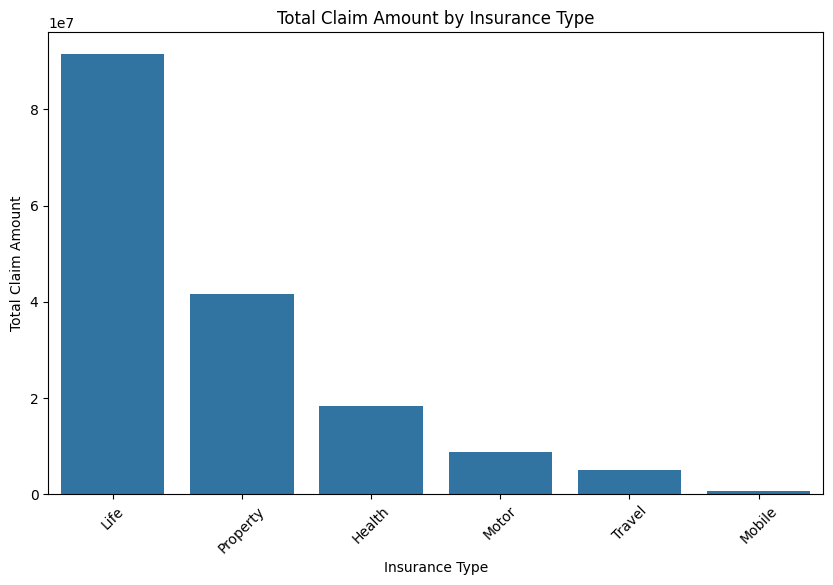

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=insurance_type_summary,
    x="INSURANCE_TYPE",
    y="Total_Claim_Amount"
)

plt.title("Total Claim Amount by Insurance Type")
plt.xlabel("Insurance Type")
plt.ylabel("Total Claim Amount")
plt.xticks(rotation=45)
plt.show()

In [0]:
# Insurance Type Claim Distribution

insurance_type_distribution = insurance_type_summary.copy()

insurance_type_distribution["Claim_Percentage"] = (
    insurance_type_distribution["Claim_Count"]
    / insurance_type_distribution["Claim_Count"].sum()
    * 100
)

insurance_type_distribution[
    [
        "INSURANCE_TYPE",
        "Claim_Count",
        "Claim_Percentage",
        "Total_Claim_Amount",
        "Average_Claim_Amount"
    ]
]

,INSURANCE_TYPE,Claim_Count,Claim_Percentage,Total_Claim_Amount,Average_Claim_Amount
1,Life,1682,16.82,91478000,54386.444709
4,Property,1692,16.92,41579000,24573.877069
0,Health,1690,16.90,18254000,10801.183432
3,Motor,1574,15.74,8663000,5503.811944
5,Travel,1670,16.70,4976000,2979.640719
2,Mobile,1692,16.92,688300,406.79669


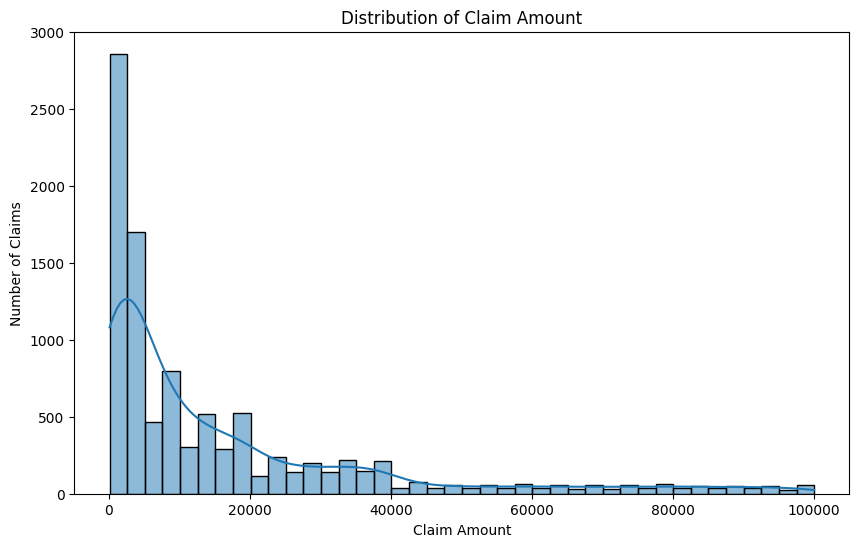

In [0]:
plt.figure(figsize=(10, 6))

sns.histplot(
    insurance_df["CLAIM_AMOUNT"],
    bins=40,
    kde=True
)

plt.title("Distribution of Claim Amount")
plt.xlabel("Claim Amount")
plt.ylabel("Number of Claims")
plt.show()

In [0]:

# Risk Segmentation Analysis

risk_summary = (
    insurance_df
    .groupby("RISK_SEGMENTATION")
    .agg(
        Claim_Count=("TRANSACTION_ID", "count"),
        Total_Claim_Amount=("CLAIM_AMOUNT", "sum"),
        Average_Claim_Amount=("CLAIM_AMOUNT", "mean")
    )
    .reset_index()
)

display(risk_summary)

RISK_SEGMENTATION,Claim_Count,Total_Claim_Amount,Average_Claim_Amount
H,1455,24481000,16825.429553264607
L,4395,72602400,16519.317406143346
M,4150,68554900,16519.253012048193


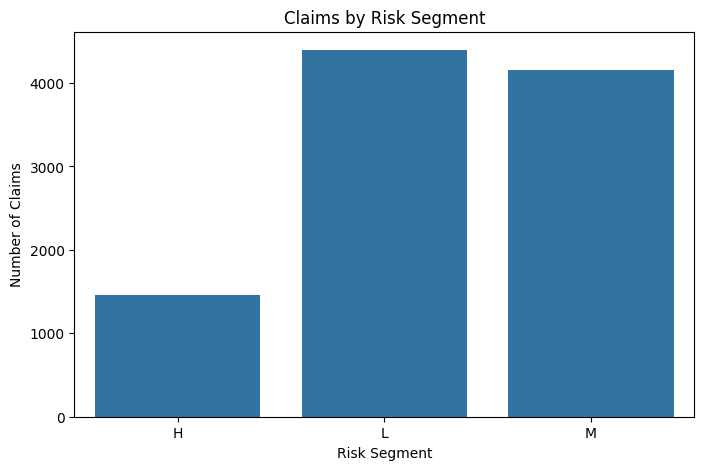

In [0]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=risk_summary,
    x="RISK_SEGMENTATION",
    y="Claim_Count"
)

plt.title("Claims by Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Number of Claims")
plt.show()

In [0]:
# Incident Severity Analysis

severity_summary = (
    insurance_df
    .groupby("INCIDENT_SEVERITY")
    .agg(
        Claim_Count=("TRANSACTION_ID", "count"),
        Total_Claim_Amount=("CLAIM_AMOUNT", "sum"),
        Average_Claim_Amount=("CLAIM_AMOUNT", "mean")
    )
    .reset_index()
)

display(severity_summary)

INCIDENT_SEVERITY,Claim_Count,Total_Claim_Amount,Average_Claim_Amount
Major Loss,3317,55249900,16656.587277660536
Minor Loss,3293,53450900,16231.673246279988
Total Loss,3390,56937500,16795.722713864307


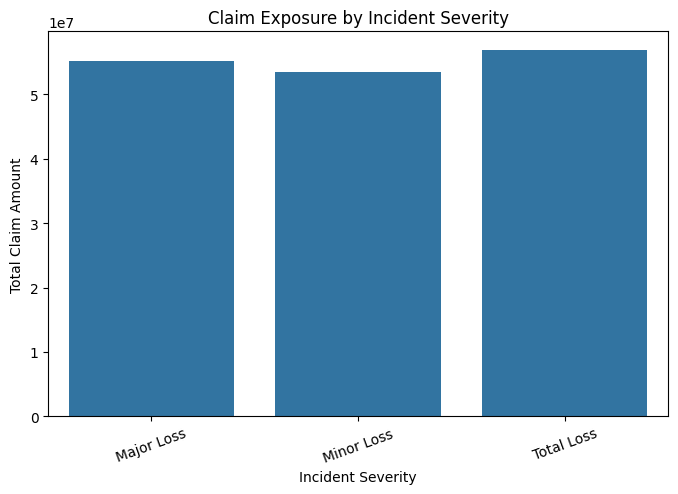

In [0]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=severity_summary,
    x="INCIDENT_SEVERITY",
    y="Total_Claim_Amount"
)

plt.title("Claim Exposure by Incident Severity")
plt.xlabel("Incident Severity")
plt.ylabel("Total Claim Amount")
plt.xticks(rotation=20)
plt.show()

In [0]:
# Claim Status Analysis

claim_status_summary = (
    insurance_df
    .groupby("CLAIM_STATUS")
    .agg(
        Claim_Count=("TRANSACTION_ID", "count"),
        Total_Claim_Amount=("CLAIM_AMOUNT", "sum"),
        Average_Claim_Amount=("CLAIM_AMOUNT", "mean")
    )
    .reset_index()
)

claim_status_summary["Claim_Percentage"] = (
    claim_status_summary["Claim_Count"]
    / claim_status_summary["Claim_Count"].sum()
    * 100
)

display(claim_status_summary)

CLAIM_STATUS,Claim_Count,Total_Claim_Amount,Average_Claim_Amount,Claim_Percentage
A,9497,157182500,16550.752869327156,94.97
D,503,8455800,16810.735586481114,5.029999999999999


In [0]:
# Claim Amount Analysis

claim_amount_summary = insurance_df[
    "CLAIM_AMOUNT"
].describe()

display(claim_amount_summary)

count     10000
unique      107
top        1000
freq        585
Name: CLAIM_AMOUNT, dtype: object

In [0]:
insurance_df.head()

,TRANSACTION_ID,CUSTOMER_ID,POLICY_NUMBER,TXN_DATE_TIME,POLICY_EFF_DT,LOSS_DT,REPORT_DT,INSURANCE_TYPE,PREMIUM_AMOUNT,CLAIM_AMOUNT,CLAIM_TO_PREMIUM_RATIO,CITY,STATE,MARITAL_STATUS,AGE,AGE_GROUP,TENURE,TENURE_GROUP,EMPLOYMENT_STATUS,NO_OF_FAMILY_MEMBERS,RISK_SEGMENTATION,HOUSE_TYPE,SOCIAL_CLASS,CUSTOMER_EDUCATION_LEVEL,CLAIM_STATUS,INCIDENT_SEVERITY,AUTHORITY_CONTACTED,ANY_INJURY,POLICE_REPORT_AVAILABLE,INCIDENT_STATE,INCIDENT_CITY,INCIDENT_HOUR_OF_THE_DAY,AGENT_ID,VENDOR_ID,REPORTING_DELAY_DAYS,REPORTING_CATEGORY,CLAIM_VALUE_CATEGORY,LOSS_YEAR,LOSS_MONTH,LOSS_MONTH_NAME
0,TXN00000001,A00003822,PLC00008468,2020-06-01,2015-06-23,2020-05-16,2020-05-21,Health,157.13,9000,57.28,Glendale,AZ,true,54,50-59,89,7-9.9 Years,true,3,L,Own,LI,Bachelor,A,Major Loss,Police,0,1,GA,Savannah,4,AGENT00413,VNDR00556,5,Delayed,Standard,2020,5,May
1,TXN00000002,A00008149,PLC00009594,2020-06-01,2018-04-21,2020-05-13,2020-05-18,Property,141.71,26000,183.47,Arvada,CO,false,61,60-64,80,5-6.9 Years,true,4,L,Rent,MI,Bachelor,A,Total Loss,Ambulance,1,0,AL,Montgomery,0,AGENT00769,VNDR00592,5,Delayed,Standard,2020,5,May
2,TXN00000003,A00003172,PLC00007969,2020-06-01,2019-10-03,2020-05-21,2020-05-26,Property,157.24,13000,82.68,Vallejo,CA,false,47,40-49,68,5-6.9 Years,true,6,L,Rent,MI,PhD,A,Total Loss,Police,0,1,CO,Grand Junction,19,AGENT00883,VNDR00031,5,Delayed,Standard,2020,5,May
3,TXN00000004,A00007572,PLC00009292,2020-06-01,2016-11-29,2020-05-14,2020-05-19,Health,172.87,16000,92.56,Thunderbolt,GA,true,36,30-39,16,<2 Years,true,7,L,Mortgage,MI,Masters,A,Minor Loss,Ambulance,0,0,GA,Savannah,12,AGENT00278,VNDR00075,5,Delayed,Standard,2020,5,May
4,TXN00000005,A00008173,PLC00000204,2020-06-01,2011-12-26,2020-05-17,2020-05-22,Travel,88.53,3000,33.89,Livermore,CA,true,51,50-59,16,<2 Years,true,2,M,Rent,HI,Masters,A,Major Loss,Police,0,1,TN,Nashville,18,AGENT00636,VNDR00472,5,Delayed,Standard,2020,5,May


In [0]:
# Age Group Analysis

age_group_summary = (
    insurance_df
    .groupby("AGE_GROUP")
    .agg(
        Claim_Count=("TRANSACTION_ID", "count"),
        Total_Claim_Amount=("CLAIM_AMOUNT", "sum"),
        Average_Claim_Amount=("CLAIM_AMOUNT", "mean")
    )
    .reset_index()
)

display(age_group_summary)

AGE_GROUP,Claim_Count,Total_Claim_Amount,Average_Claim_Amount
25-29,1282,21277100,16596.801872074884
30-39,2452,41241100,16819.37194127243
40-49,2510,41403800,16495.537848605578
50-59,2529,40957000,16194.938710952945
60-64,1227,20759300,16918.744906275468


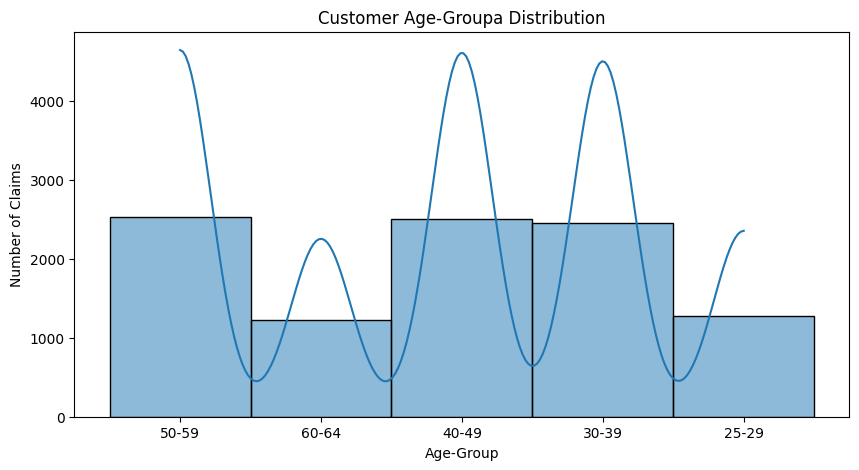

In [0]:
plt.figure(figsize=(10, 5))

sns.histplot(
    insurance_df["AGE_GROUP"],
    bins=20,
    kde=True
)

plt.title("Customer Age-Groupa Distribution")
plt.xlabel("Age-Group")
plt.ylabel("Number of Claims")
plt.show()

In [0]:
# Tenure Analysis

tenure_summary = (
    insurance_df
    .groupby("TENURE_GROUP")
    .agg(
        Claim_Count=("TRANSACTION_ID", "count"),
        Total_Claim_Amount=("CLAIM_AMOUNT", "sum"),
        Average_Claim_Amount=("CLAIM_AMOUNT", "mean")
    )
    .reset_index()
)

display(tenure_summary)

TENURE_GROUP,Claim_Count,Total_Claim_Amount,Average_Claim_Amount
2-4.9 Years,3106,52138500,16786.381197681905
5-6.9 Years,2141,35241300,16460.20551144325
7-9.9 Years,3197,52786700,16511.323115420706
<2 Years,1556,25471800,16370.051413881749


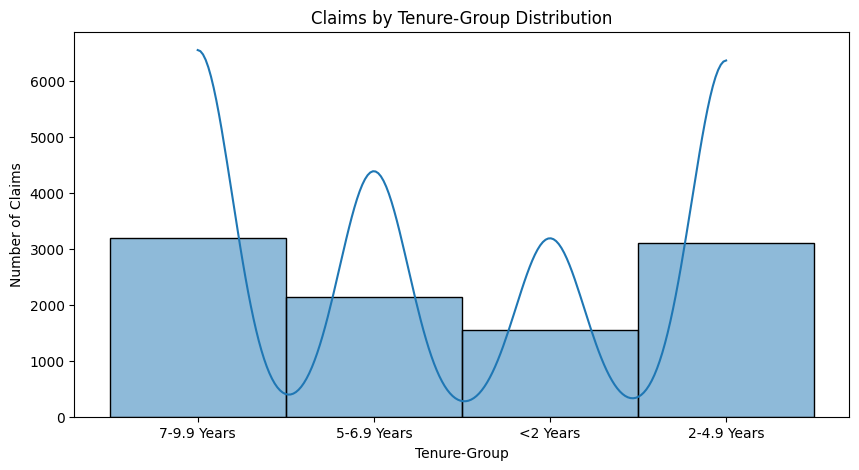

In [0]:
plt.figure(figsize=(10, 5))

sns.histplot(
    insurance_df["TENURE_GROUP"],
    bins=20,
    kde=True
)

plt.title("Claims by Tenure-Group Distribution")
plt.xlabel("Tenure-Group")
plt.ylabel("Number of Claims")
plt.show()

In [0]:
# Geographic Analysis

state_summary = (
    insurance_df
    .groupby("STATE")
    .agg(
        Claim_Count=("TRANSACTION_ID", "count"),
        Total_Claim_Amount=("CLAIM_AMOUNT", "sum"),
        Average_Claim_Amount=("CLAIM_AMOUNT", "mean")
    )
    .reset_index()
    .sort_values(
        "Total_Claim_Amount",
        ascending=False
    )
)

display(state_summary.head(15))

STATE,Claim_Count,Total_Claim_Amount,Average_Claim_Amount
CA,1035,18075600,17464.347826086956
AR,644,11656800,18100.621118012423
GA,613,11291600,18420.228384991842
TN,641,10720800,16725.11700468019
CO,677,10582500,15631.462333825702
FL,650,10502000,16156.923076923076
AL,623,10420700,16726.645264847513
AZ,603,10039400,16649.087893864013
VT,579,9591400,16565.45768566494
DC,581,9369500,16126.506024096385


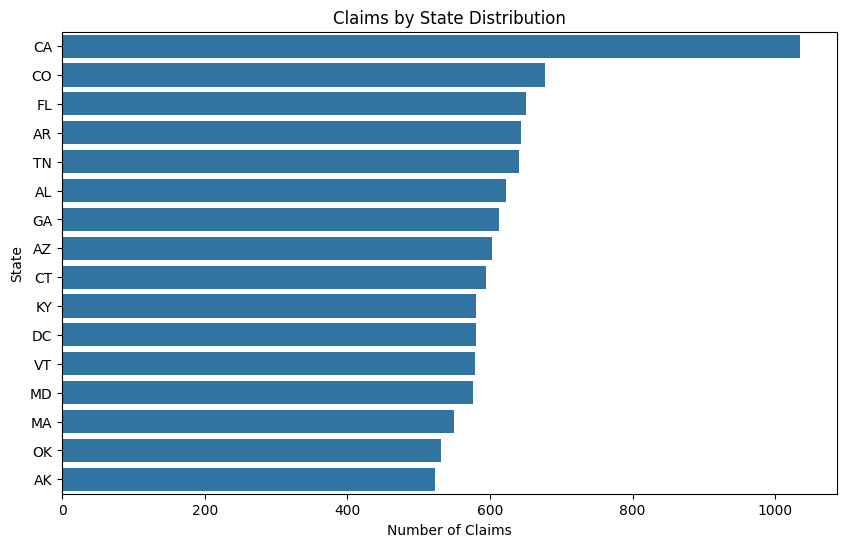

In [0]:
# Claims by State


plt.figure(figsize=(10, 6))

order = (
    insurance_df["STATE"]
    .value_counts()
    .index
)

sns.countplot(
    data=insurance_df,
    y="STATE",
    order=order
)

plt.title("Claims by State Distribution")
plt.xlabel("Number of Claims")
plt.ylabel("State")

plt.show()

In [0]:
# Reporting Behavior

reporting_summary = (
    insurance_df
    .groupby("REPORTING_CATEGORY")
    .agg(
        Claim_Count=("TRANSACTION_ID", "count"),
        Total_Claim_Amount=("CLAIM_AMOUNT", "sum"),
        Average_Claim_Amount=("CLAIM_AMOUNT", "mean"),
        Average_Reporting_Delay=("REPORTING_DELAY_DAYS", "mean")
    )
    .reset_index()
)

reporting_summary["Claim_Percentage"] = (
    reporting_summary["Claim_Count"]
    / reporting_summary["Claim_Count"].sum()
    * 100
)

display(reporting_summary)

REPORTING_CATEGORY,Claim_Count,Total_Claim_Amount,Average_Claim_Amount,Average_Reporting_Delay,Claim_Percentage
Delayed,8435,139079100,16488.33432128038,3.807705986959099,84.35000000000001
Same Day,1565,26559200,16970.73482428115,0.0,15.65


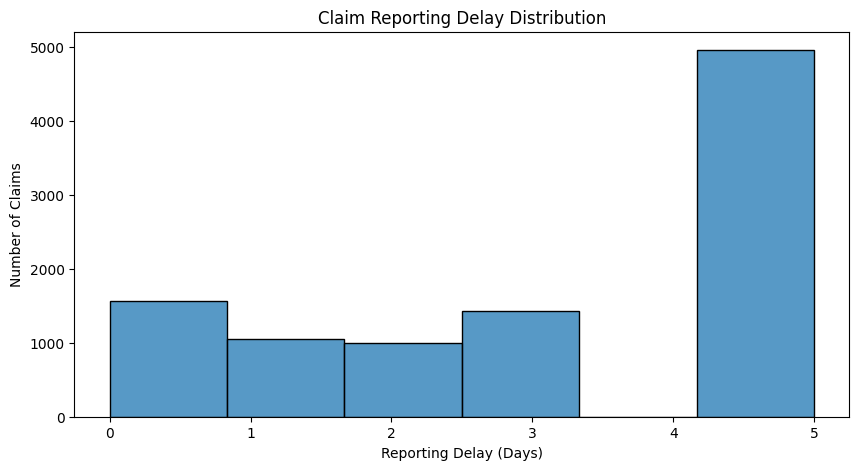

In [0]:
plt.figure(figsize=(10, 5))

sns.histplot(
    insurance_df["REPORTING_DELAY_DAYS"],
    bins=6
)

plt.title("Claim Reporting Delay Distribution")
plt.xlabel("Reporting Delay (Days)")
plt.ylabel("Number of Claims")
plt.show()

In [0]:
# Injury Analysis


injury_summary = (
    insurance_df
    .groupby("ANY_INJURY")
    .agg(
        Claim_Count=("TRANSACTION_ID", "count"),
        Total_Claim_Amount=("CLAIM_AMOUNT", "sum"),
        Average_Claim_Amount=("CLAIM_AMOUNT", "mean")
    )
    .reset_index()
)

display(injury_summary)

ANY_INJURY,Claim_Count,Total_Claim_Amount,Average_Claim_Amount
0,3009,48657300,16170.588235294117
1,6991,116981000,16733.08539550851


In [0]:
# Police Report Analysis
police_report_summary = (
    insurance_df
    .groupby("POLICE_REPORT_AVAILABLE")
    .agg(
        Claim_Count=("TRANSACTION_ID", "count"),
        Total_Claim_Amount=("CLAIM_AMOUNT", "sum"),
        Average_Claim_Amount=("CLAIM_AMOUNT", "mean")
    )
    .reset_index()
)

display(police_report_summary)

POLICE_REPORT_AVAILABLE,Claim_Count,Total_Claim_Amount,Average_Claim_Amount
0,3072,50347100,16389.029947916668
1,6928,115291200,16641.33949191686


In [0]:
# Monthly Claims Analysis


monthly_summary = (
    insurance_df
    .groupby(
        [
            "LOSS_YEAR",
            "LOSS_MONTH",
            "LOSS_MONTH_NAME"
        ]
    )
    .agg(
        Claim_Count=("TRANSACTION_ID", "count"),
        Total_Claim_Amount=("CLAIM_AMOUNT", "sum"),
        Average_Claim_Amount=("CLAIM_AMOUNT", "mean")
    )
    .reset_index()
    .sort_values(
        [
            "LOSS_YEAR",
            "LOSS_MONTH"
        ]
    )
)

display(monthly_summary)

LOSS_YEAR,LOSS_MONTH,LOSS_MONTH_NAME,Claim_Count,Total_Claim_Amount,Average_Claim_Amount
2020,5,May,288,5210900,18093.402777777777
2020,6,June,730,11832700,16209.17808219178
2020,7,July,765,11902500,15558.823529411764
2020,8,August,737,12186800,16535.685210312076
2020,9,September,749,13118700,17514.953271028036
2020,10,October,781,12313100,15765.813060179258
2020,11,November,752,12004900,15963.962765957447
2020,12,December,828,14210200,17162.07729468599
2021,1,January,810,14245600,17587.16049382716
2021,2,February,719,11710600,16287.343532684285


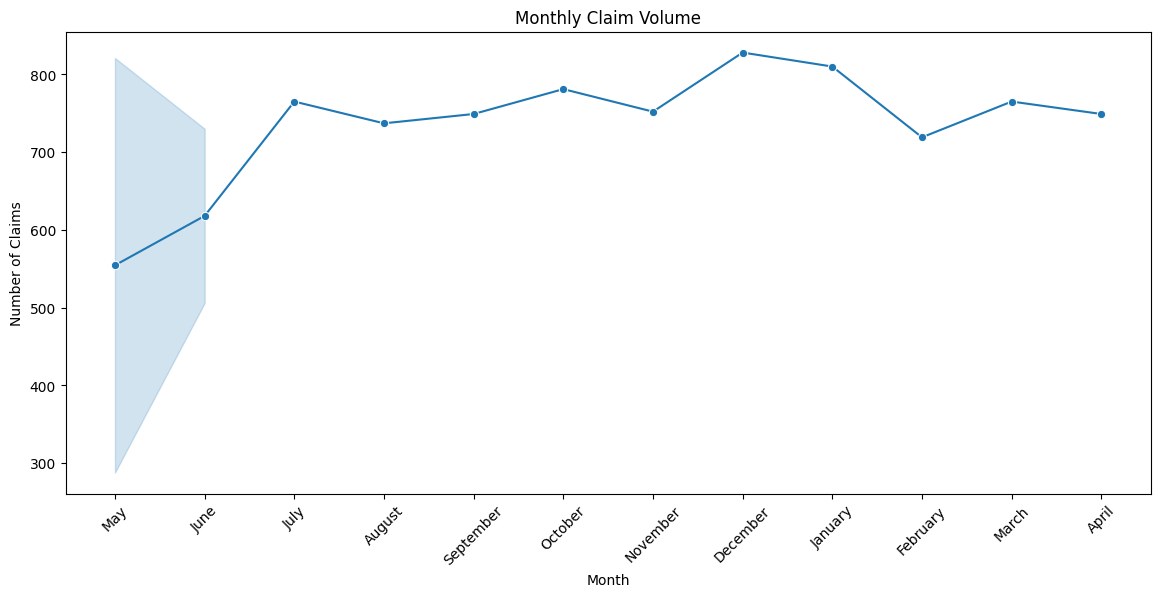

In [0]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_summary,
    x="LOSS_MONTH_NAME",
    y="Claim_Count",
    marker="o"
)

plt.title("Monthly Claim Volume")
plt.xlabel("Month")
plt.ylabel("Number of Claims")

plt.xticks(rotation=45)

plt.show()

In [0]:
# Financial Summary by Risk


risk_financial_summary = (
    insurance_df
    .groupby("RISK_SEGMENTATION")
    .agg(
        Claims=("TRANSACTION_ID", "count"),
        Total_Claim_Amount=("CLAIM_AMOUNT", "sum"),
        Average_Claim_Amount=("CLAIM_AMOUNT", "mean"),
        Total_Premium=("PREMIUM_AMOUNT", "sum"),
        Average_Premium=("PREMIUM_AMOUNT", "mean"),
        Average_Claim_to_Premium_Ratio=(
            "CLAIM_TO_PREMIUM_RATIO",
            "mean"
        )
    )
    .reset_index()
)

display(risk_financial_summary)

RISK_SEGMENTATION,Claims,Total_Claim_Amount,Average_Claim_Amount,Total_Premium,Average_Premium,Average_Claim_to_Premium_Ratio
H,1455,24481000,16825.429553264607,128281.18,88.16575945017182,201.64286597938144
L,4395,72602400,16519.317406143346,391876.26,89.16410921501706,199.46228213879408
M,4150,68554900,16519.253012048193,364928.51,87.93458072289157,198.20877831325302


In [0]:
# Top 10 Highest Claims


top_claims = (
    insurance_df[
        [
            "TRANSACTION_ID",
            "CUSTOMER_ID",
            "INSURANCE_TYPE",
            "RISK_SEGMENTATION",
            "INCIDENT_SEVERITY",
            "CLAIM_AMOUNT",
            "PREMIUM_AMOUNT",
            "REPORTING_DELAY_DAYS"
        ]
    ]
    .sort_values(
        "CLAIM_AMOUNT",
        ascending=False
    )
    .head(10)
)

display(top_claims)

TRANSACTION_ID,CUSTOMER_ID,INSURANCE_TYPE,RISK_SEGMENTATION,INCIDENT_SEVERITY,CLAIM_AMOUNT,PREMIUM_AMOUNT,REPORTING_DELAY_DAYS
TXN00006351,A00001728,Life,L,Major Loss,100000,95.16,5
TXN00007680,A00005522,Life,M,Minor Loss,100000,81.44,3
TXN00004319,A00006831,Life,M,Major Loss,100000,97.99,5
TXN00002414,A00009661,Life,M,Minor Loss,100000,98.24,1
TXN00000117,A00008706,Life,M,Total Loss,100000,82.01,3
TXN00009622,A00002256,Life,M,Major Loss,100000,83.92,5
TXN00000669,A00002243,Life,L,Minor Loss,100000,97.8,5
TXN00004210,A00004501,Life,L,Total Loss,100000,81.36,1
TXN00005508,A00005621,Life,L,Minor Loss,100000,62.36,5
TXN00004641,A00002705,Life,L,Major Loss,100000,55.32,2


# DIAGNOSTIC ANALYSIS

In [0]:
# Risk × Incident Severity

risk_severity = pd.crosstab(
    insurance_df["RISK_SEGMENTATION"],
    insurance_df["INCIDENT_SEVERITY"]
)

display(risk_severity)

Major Loss,Minor Loss,Total Loss
462,493,500
1439,1453,1503
1416,1347,1387


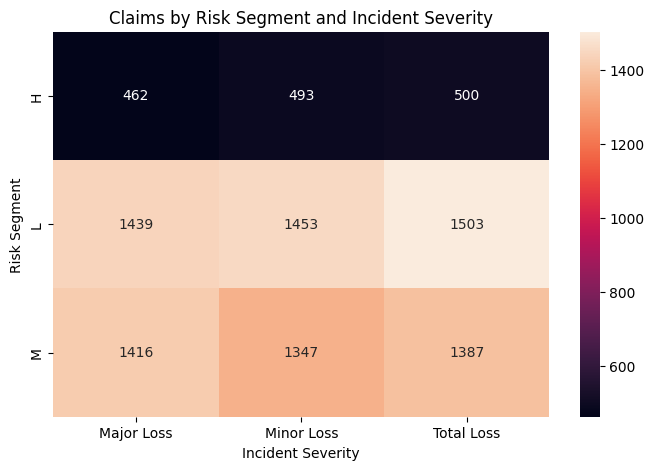

In [0]:
# Visualization
plt.figure(figsize=(8, 5))

sns.heatmap(
    risk_severity,
    annot=True,
    fmt="d"
)

plt.title("Claims by Risk Segment and Incident Severity")
plt.xlabel("Incident Severity")
plt.ylabel("Risk Segment")
plt.show()

In [0]:
# Insurance Type × Risk
insurance_risk = pd.crosstab(
    insurance_df["INSURANCE_TYPE"],
    insurance_df["RISK_SEGMENTATION"]
)

display(insurance_risk)

H,L,M
242,753,695
251,731,700
252,720,720
210,716,648
265,719,708
235,756,679


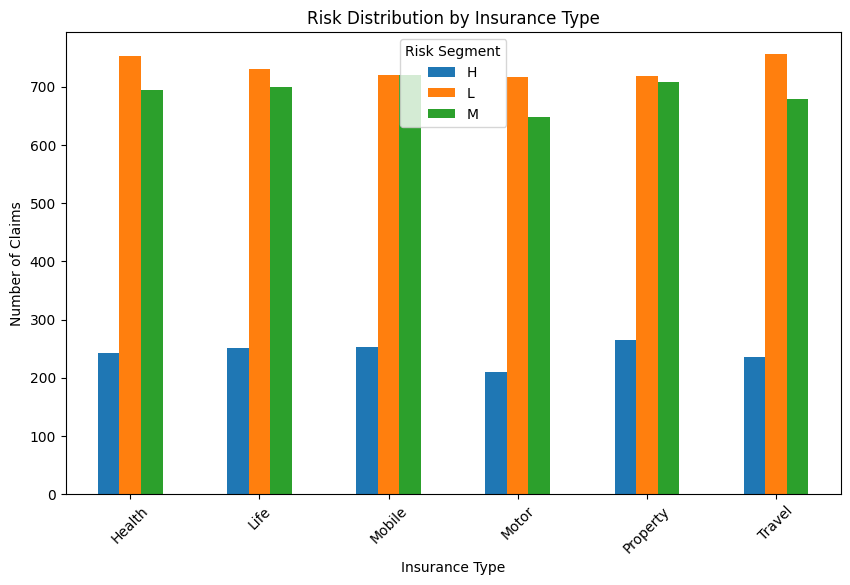

In [0]:
# Chart
insurance_risk.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Risk Distribution by Insurance Type")
plt.xlabel("Insurance Type")
plt.ylabel("Number of Claims")
plt.xticks(rotation=45)
plt.legend(title="Risk Segment")
plt.show()

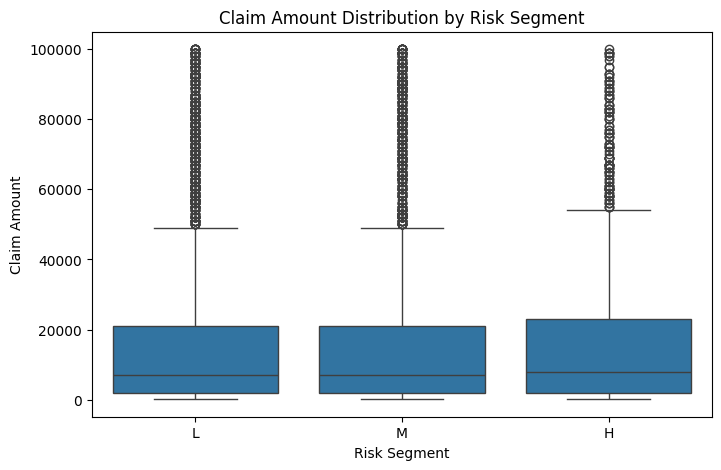

In [0]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=insurance_df,
    x="RISK_SEGMENTATION",
    y="CLAIM_AMOUNT"
)

plt.title("Claim Amount Distribution by Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Claim Amount")
plt.show()

In [0]:
# Insurance Type × Severity
insurance_severity = pd.crosstab(
    insurance_df["INSURANCE_TYPE"],
    insurance_df["INCIDENT_SEVERITY"]
)

display(insurance_severity)

Major Loss,Minor Loss,Total Loss
566,546,578
591,527,564
553,572,567
539,523,512
543,556,593
525,569,576


In [0]:
# Severity × Claim Amount
severity_claim = (
    insurance_df
    .groupby("INCIDENT_SEVERITY")
    .agg(
        Claim_Count=("TRANSACTION_ID", "count"),
        Total_Claim_Amount=("CLAIM_AMOUNT", "sum"),
        Average_Claim_Amount=("CLAIM_AMOUNT", "mean"),
        Median_Claim_Amount=("CLAIM_AMOUNT", "median")
    )
    .reset_index()
)

display(severity_claim)

INCIDENT_SEVERITY,Claim_Count,Total_Claim_Amount,Average_Claim_Amount,Median_Claim_Amount
Major Loss,3317,55249900,16656.587277660536,8000.0
Minor Loss,3293,53450900,16231.673246279988,7000.0
Total Loss,3390,56937500,16795.722713864307,7000.0


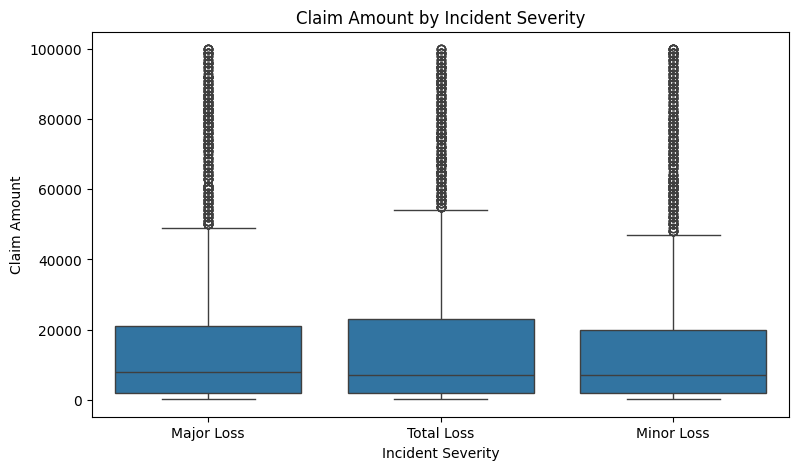

In [0]:
# Chart
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=insurance_df,
    x="INCIDENT_SEVERITY",
    y="CLAIM_AMOUNT"
)

plt.title("Claim Amount by Incident Severity")
plt.xlabel("Incident Severity")
plt.ylabel("Claim Amount")
plt.show()

In [0]:
# Injury × Severity
injury_severity = pd.crosstab(
    insurance_df["ANY_INJURY"],
    insurance_df["INCIDENT_SEVERITY"]
)

display(injury_severity)

Major Loss,Minor Loss,Total Loss
993,1006,1010
2324,2287,2380


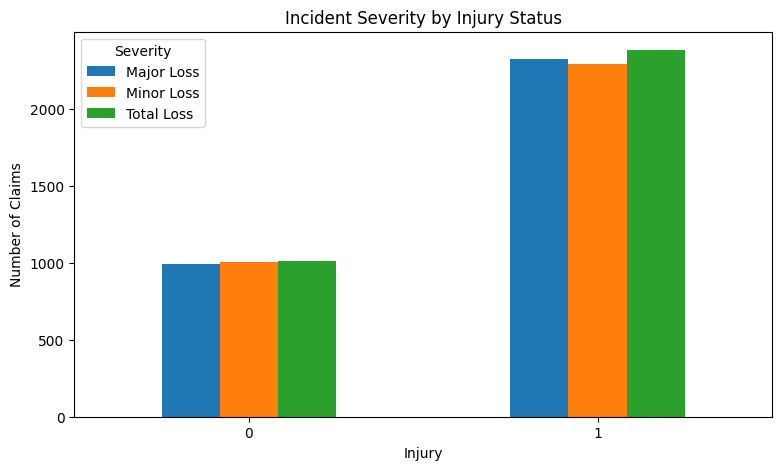

In [0]:
# Visualization:

injury_severity.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Incident Severity by Injury Status")
plt.xlabel("Injury")
plt.ylabel("Number of Claims")
plt.xticks(rotation=0)
plt.legend(title="Severity")
plt.show()

In [0]:
# Police Report × Severity
police_severity = pd.crosstab(
    insurance_df["POLICE_REPORT_AVAILABLE"],
    insurance_df["INCIDENT_SEVERITY"]
)

display(police_severity)

Major Loss,Minor Loss,Total Loss
965,1054,1053
2352,2239,2337


In [0]:
# Reporting Delay × Claim Amount
delay_claim = (
    insurance_df
    .groupby("REPORTING_CATEGORY")
    .agg(
        Claim_Count=("TRANSACTION_ID", "count"),
        Average_Claim_Amount=("CLAIM_AMOUNT", "mean"),
        Total_Claim_Amount=("CLAIM_AMOUNT", "sum")
    )
    .reset_index()
)

display(delay_claim)

REPORTING_CATEGORY,Claim_Count,Average_Claim_Amount,Total_Claim_Amount
Delayed,8435,16488.33432128038,139079100
Same Day,1565,16970.73482428115,26559200


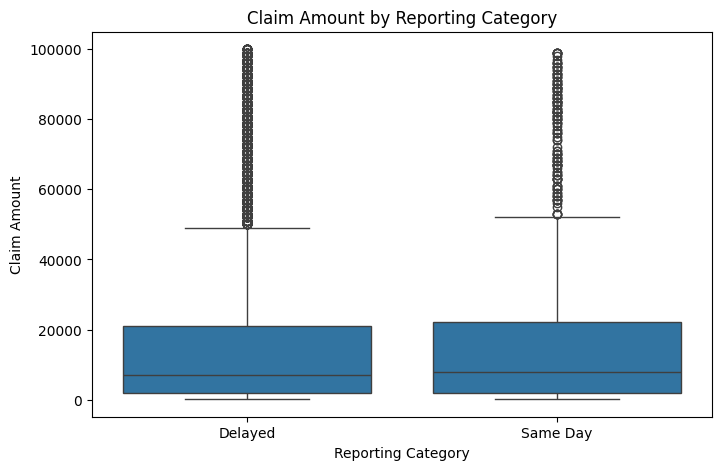

In [0]:
# Chart
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=insurance_df,
    x="REPORTING_CATEGORY",
    y="CLAIM_AMOUNT"
)

plt.title("Claim Amount by Reporting Category")
plt.xlabel("Reporting Category")
plt.ylabel("Claim Amount")
plt.show()

In [0]:
# Insurance Type × Severity
insurance_severity_percentage = pd.crosstab(
    insurance_df["INSURANCE_TYPE"],
    insurance_df["INCIDENT_SEVERITY"],
    normalize="index"
) * 100

display(
    insurance_severity_percentage.round(2)
)

Major Loss,Minor Loss,Total Loss
33.49,32.31,34.2
35.14,31.33,33.53
32.68,33.81,33.51
34.24,33.23,32.53
32.09,32.86,35.05
31.44,34.07,34.49


In [0]:
# Agent Analysis
agent_analysis = (
    insurance_df
    .groupby("AGENT_ID")
    .agg(
        Claim_Count=("TRANSACTION_ID", "count"),
        Total_Claim_Amount=("CLAIM_AMOUNT", "sum"),
        Average_Claim_Amount=("CLAIM_AMOUNT", "mean"),
        Average_Reporting_Delay=("REPORTING_DELAY_DAYS", "mean")
    )
    .reset_index()
    .sort_values("Total_Claim_Amount", ascending=False)
)

display(agent_analysis.head(10))

AGENT_ID,Claim_Count,Total_Claim_Amount,Average_Claim_Amount,Average_Reporting_Delay
AGENT00807,14,528800,37771.42857142857,3.0
AGENT00679,13,489000,37615.38461538462,2.923076923076923
AGENT00771,15,422100,28140.0,3.3333333333333335
AGENT00125,10,400400,40040.0,3.6
AGENT00789,9,392900,43655.555555555555,1.8888888888888888
AGENT00525,15,385900,25726.666666666668,3.1333333333333333
AGENT00319,18,375600,20866.666666666668,2.9444444444444446
AGENT00388,17,373800,21988.235294117647,3.7058823529411766
AGENT00439,12,370000,30833.333333333332,3.9166666666666665
AGENT00482,11,368000,33454.545454545456,3.3636363636363638


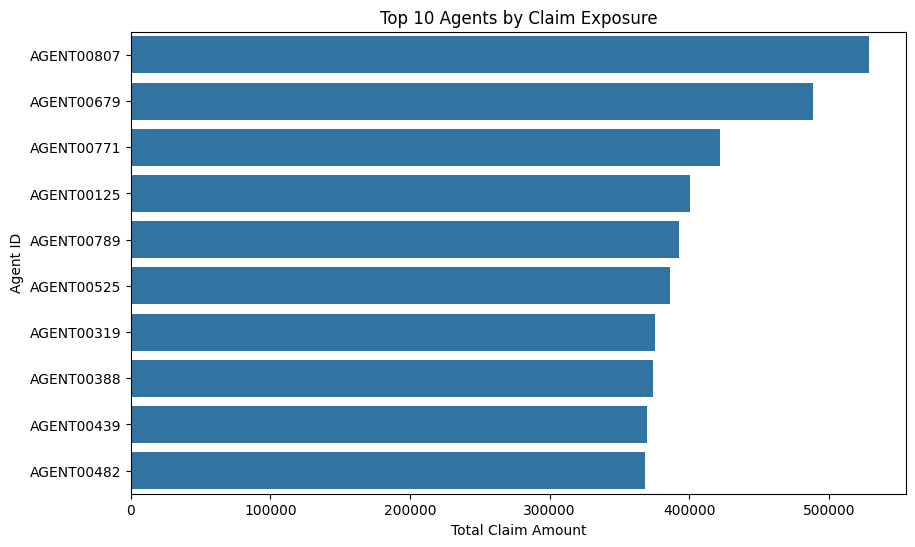

In [0]:
# Chart
top_agents = agent_analysis.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_agents,
    x="Total_Claim_Amount",
    y="AGENT_ID"
)

plt.title("Top 10 Agents by Claim Exposure")
plt.xlabel("Total Claim Amount")
plt.ylabel("Agent ID")
plt.show()

In [0]:
# Agent Analysis

vendor_analysis = (
    insurance_df.dropna(subset=["VENDOR_ID"])
    .groupby("VENDOR_ID")
    .agg(
        Claim_Count=("TRANSACTION_ID", "count"),
        Total_Claim_Amount=("CLAIM_AMOUNT", "sum"),
        Average_Claim_Amount=("CLAIM_AMOUNT", "mean")
    )
    .reset_index()
    .sort_values("Total_Claim_Amount", ascending=False)
)

display(vendor_analysis.head(10))

VENDOR_ID,Claim_Count,Total_Claim_Amount,Average_Claim_Amount
VNDR00445,23,661000,28739.130434782608
VNDR00453,18,635000,35277.77777777778
VNDR00031,25,608700,24348.0
VNDR00591,21,598000,28476.190476190477
VNDR00138,19,567200,29852.63157894737
VNDR00579,16,565400,35337.5
VNDR00325,18,548100,30450.0
VNDR00339,25,546300,21852.0
VNDR00425,24,542500,22604.166666666668
VNDR00232,24,526600,21941.666666666668


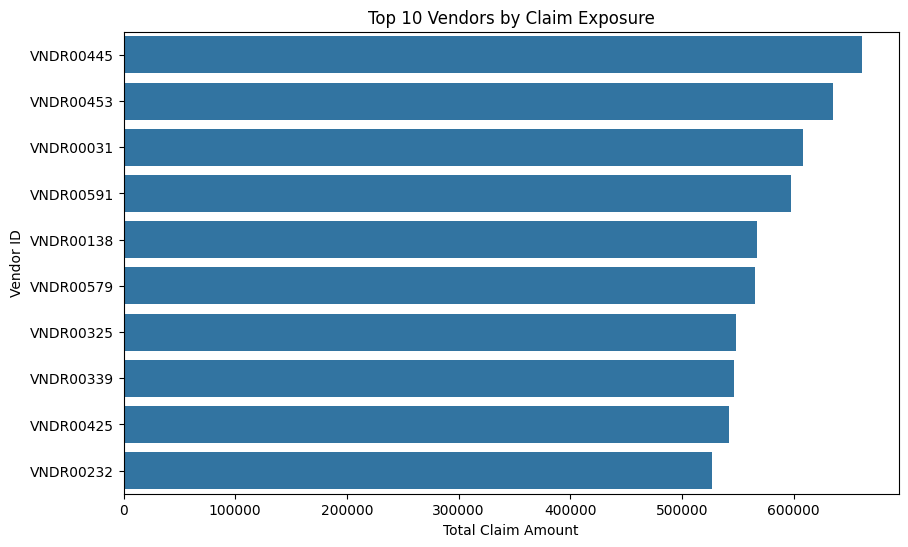

In [0]:
# Chart:

top_vendors = vendor_analysis.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_vendors,
    x="Total_Claim_Amount",
    y="VENDOR_ID"
)

plt.title("Top 10 Vendors by Claim Exposure")
plt.xlabel("Total Claim Amount")
plt.ylabel("Vendor ID")
plt.show()

In [0]:
injury_severity_percentage = pd.crosstab(
    insurance_df["ANY_INJURY"],
    insurance_df["INCIDENT_SEVERITY"],
    normalize="index"
) * 100

display(
    injury_severity_percentage.round(2)
)

Major Loss,Minor Loss,Total Loss
33.0,33.43,33.57
33.24,32.71,34.04


# Predictive Modeling: Claim Amount Prediction

In [0]:
# -- Select Features
model_columns = [
    "INSURANCE_TYPE",
    "AGE",
    "TENURE",
    "RISK_SEGMENTATION",
    "INCIDENT_SEVERITY",
    "MARITAL_STATUS",
    "EMPLOYMENT_STATUS",
    "HOUSE_TYPE",
    "SOCIAL_CLASS",
    "CUSTOMER_EDUCATION_LEVEL",
    "ANY_INJURY",
    "POLICE_REPORT_AVAILABLE",
    "INCIDENT_HOUR_OF_THE_DAY",
    "REPORTING_DELAY_DAYS"
]

X = insurance_df[model_columns]
y = insurance_df["CLAIM_AMOUNT"]

In [0]:
# Separate Numerical & Categorical Features
categorical_features = [
    "INSURANCE_TYPE",
    "RISK_SEGMENTATION",
    "INCIDENT_SEVERITY",
    "MARITAL_STATUS",
    "EMPLOYMENT_STATUS",
    "HOUSE_TYPE",
    "SOCIAL_CLASS",
    "CUSTOMER_EDUCATION_LEVEL",
    "ANY_INJURY",
    "POLICE_REPORT_AVAILABLE"
]

numerical_features = [
    "AGE",
    "TENURE",
    "INCIDENT_HOUR_OF_THE_DAY",
    "REPORTING_DELAY_DAYS"
]

In [0]:
# Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 8000
Testing rows: 2000


In [0]:
# Preprocessing Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [0]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)
numeric_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])

In [0]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)
categorical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

In [0]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['AGE', 'TENURE', 'INCIDENT_HOUR_OF_THE_DAY',
                                  'REPORTING_DELAY_DAYS']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['INSURANCE_TYPE', 'RISK_SEGMENTATION',
                                  'INCIDENT_SEVERITY', 'MARITAL_STATUS',
                                  'EMPLOYMENT_STATUS', 'HOUSE_TYPE',
                                  'SOCIAL_CLASS', 'CUSTOMER_EDUCATION_LEVEL',
                                  'ANY_INJURY', 'POLICE_REPORT_AVAILABLE'])])

In [0]:
# Model 1: Linear Regression
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)
linear_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['AGE', 'TENURE',
                                                   'INCIDENT_HOUR_OF_THE_DAY',
                                                   'REPORTING_DELAY_DAYS']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['INSURANCE_TYPE',
                                                   'RISK_SEGMENTATION',
                                                   'INCIDENT_SEVERITY',
                                                   'MARITAL_STATUS',
                                                   'EMPLOYMENT_STATUS',
                                                   'HOUSE_TYPE', 'SOCIAL_CLASS',
                                                   'CUSTOMER_EDUCATION_LEVEL',
                                                   'ANY_INJURY',
                                                   'POLICE_REPORT_AVAILABLE'])])),
                ('model', LinearRegression())])

In [0]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['AGE', 'TENURE',
                                                   'INCIDENT_HOUR_OF_THE_DAY',
                                                   'REPORTING_DELAY_DAYS']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['INSURANCE_TYPE',
                                                   'RISK_SEGMENTATION',
                                                   'INCIDENT_SEVERITY',
                                                   'MARITAL_STATUS',
                                                   'EMPLOYMENT_STATUS',
                                                   'HOUSE_TYPE', 'SOCIAL_CLASS',
                                                   'CUSTOMER_EDUCATION_LEVEL',
                                                   'ANY_INJURY',
                                                   'POLICE_REPORT_AVAILABLE'])])),
                ('model', LinearRegression())])

In [0]:
linear_predictions = linear_model.predict(X_test)
linear_predictions


array([ 2991.44137747,  1563.84067289,  3430.63082665, ...,
        2032.46031827, 55566.69453213,  3623.32677131])

In [0]:
# Model 2: Random Forest
from sklearn.ensemble import RandomForestRegressor

In [0]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
         ]
                            )

random_forest_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['AGE', 'TENURE',
                                                   'INCIDENT_HOUR_OF_THE_DAY',
                                                   'REPORTING_DELAY_DAYS']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['INSURANCE_TYPE',
                                                   'RISK_SEGMENTATION',
                                                   'INCIDENT_SEVERITY',
                                                   'MARITAL_STATUS',
                                                   'EMPLOYMENT_STATUS',
                                                   'HOUSE_TYPE', 'SOCIAL_CLASS',
                                                   'CUSTOMER_EDUCATION_LEVEL',
                                                   'ANY_INJURY',
                                                   'POLICE_REPORT_AVAILABLE'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [0]:
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['AGE', 'TENURE',
                                                   'INCIDENT_HOUR_OF_THE_DAY',
                                                   'REPORTING_DELAY_DAYS']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['INSURANCE_TYPE',
                                                   'RISK_SEGMENTATION',
                                                   'INCIDENT_SEVERITY',
                                                   'MARITAL_STATUS',
                                                   'EMPLOYMENT_STATUS',
                                                   'HOUSE_TYPE', 'SOCIAL_CLASS',
                                                   'CUSTOMER_EDUCATION_LEVEL',
                                                   'ANY_INJURY',
                                                   'POLICE_REPORT_AVAILABLE'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [0]:
rf_predictions = random_forest_model.predict(X_test)
rf_predictions

array([ 3280. ,   372.5,  3605. , ...,   399. , 63660. ,  2940. ])

In [0]:
# Evaluate Both Models
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [0]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

In [0]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

In [0]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2
    ]
})

model_comparison

,Model,MAE,RMSE,R2
0,Linear Regression,6935.147155,11976.843461,0.706562
1,Random Forest,6903.990250,12250.858013,0.692981


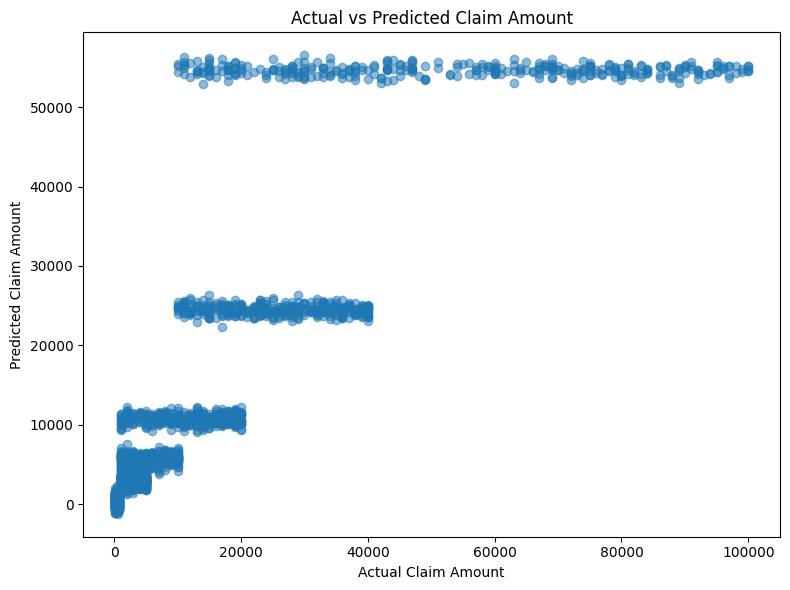

In [0]:
# Actual vs Predicted Plot

best_predictions = linear_predictions

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.5
)

plt.xlabel("Actual Claim Amount")
plt.ylabel("Predicted Claim Amount")
plt.title("Actual vs Predicted Claim Amount")

plt.tight_layout()
plt.show()

In [0]:
# Prediction Error

prediction_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": best_predictions
})

prediction_results["Error"] = (
    prediction_results["Actual"].astype(float)
    - prediction_results["Predicted"].astype(float)
)

prediction_results.head(10)

,Actual,Predicted,Error
0,2000,2991.441377,-991.441377
1,100,1563.840673,-1463.840673
2,3000,3430.630827,-430.630827
3,14000,24512.611729,-10512.611729
4,600,369.225700,230.774300
5,200,576.463720,-376.463720
6,17000,22296.922245,-5296.922245
7,75000,55130.618320,19869.381680
8,1000,2908.093031,-1908.093031
9,400,291.024586,108.975414


# Model Interpretation & Feature Importance

In [0]:
# Extract Random Forest Feature Importance

rf_pipeline = random_forest_model

feature_names = (
    rf_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_importances = (
    rf_pipeline
    .named_steps["model"]
    .feature_importances_
)

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance_df.head(20)

,Feature,Importance
5,cat__INSURANCE_TYPE_Life,0.600425
8,cat__INSURANCE_TYPE_Property,0.106399
1,num__TENURE,0.055448
0,num__AGE,0.046227
2,num__INCIDENT_HOUR_OF_THE_DAY,0.041483
4,cat__INSURANCE_TYPE_Health,0.016123
3,num__REPORTING_DELAY_DAYS,0.015776
26,cat__CUSTOMER_EDUCATION_LEVEL_Bachelor,0.005758
28,cat__CUSTOMER_EDUCATION_LEVEL_High School,0.005584
12,cat__RISK_SEGMENTATION_M,0.005415


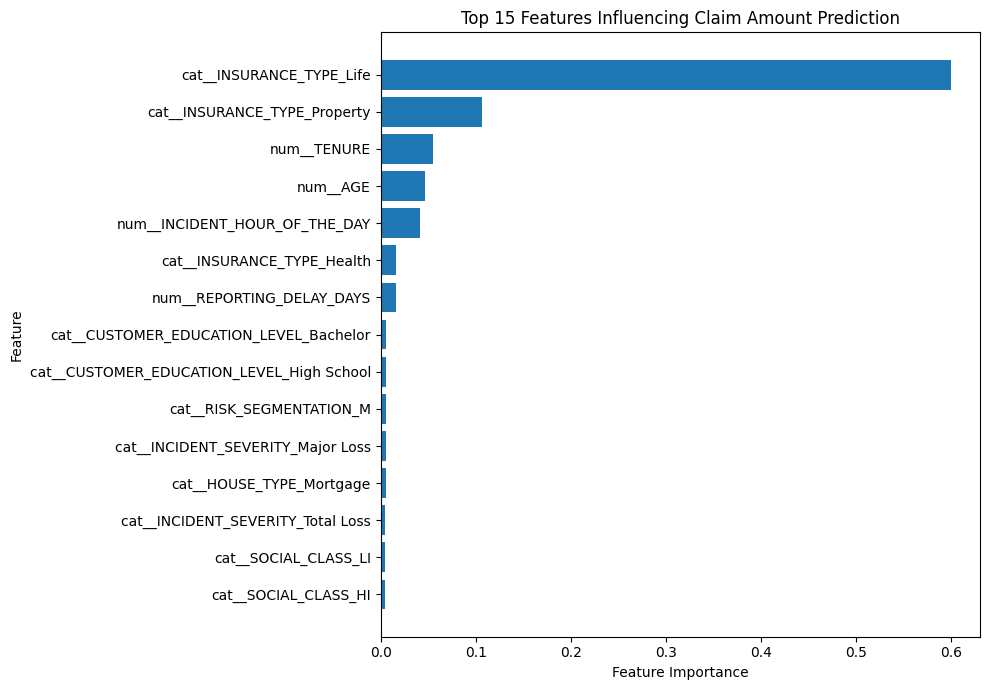

In [0]:
# Visualize Top 15 Features
top_features = feature_importance_df.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Influencing Claim Amount Prediction")

plt.tight_layout()
plt.show()

In [0]:
# Linear Regression Coefficients


linear_feature_names = (
    linear_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

linear_coefficients = (
    linear_model
    .named_steps["model"]
    .coef_
)

linear_coefficient_df = pd.DataFrame({
    "Feature": linear_feature_names,
    "Coefficient": linear_coefficients
})

linear_coefficient_df["Absolute_Coefficient"] = (
    linear_coefficient_df["Coefficient"].abs()
)

linear_coefficient_df = linear_coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

linear_coefficient_df.head(20)

,Feature,Coefficient,Absolute_Coefficient
5,cat__INSURANCE_TYPE_Life,38149.321096,38149.321096
6,cat__INSURANCE_TYPE_Mobile,-16059.295300,16059.295300
9,cat__INSURANCE_TYPE_Travel,-13524.280337,13524.280337
7,cat__INSURANCE_TYPE_Motor,-10869.619583,10869.619583
8,cat__INSURANCE_TYPE_Property,7995.191620,7995.191620
4,cat__INSURANCE_TYPE_Health,-5691.317497,5691.317497
30,cat__CUSTOMER_EDUCATION_LEVEL_Masters,-546.496104,546.496104
27,cat__CUSTOMER_EDUCATION_LEVEL_College,499.783117,499.783117
13,cat__INCIDENT_SEVERITY_Major Loss,-428.693990,428.693990
28,cat__CUSTOMER_EDUCATION_LEVEL_High School,397.608919,397.608919


In [0]:
# Compare Model Performance


model_comparison

,Model,MAE,RMSE,R2
0,Linear Regression,6935.147155,11976.843461,0.706562
1,Random Forest,6903.990250,12250.858013,0.692981


## Model Comparison

Two regression models were evaluated for predicting claim amount:
Linear Regression and Random Forest.

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Linear Regression | 6,935.15 | 11,976.84 | 0.7066 |
| Random Forest | 6,903.99 | 12,250.86 | 0.6930 |

### Model Selection

**Linear Regression** was selected as the final model based on its overall
performance across the evaluation metrics.

- Random Forest achieved a slightly lower MAE (6,903.99), indicating
  a marginally lower average absolute error.
- Linear Regression achieved a lower RMSE (11,976.84), indicating
  better performance when larger prediction errors are considered.
- Linear Regression achieved a higher R² (0.7066), explaining more
  variation in claim amounts than Random Forest (0.6930).

Therefore, Linear Regression provides the stronger overall performance
for this dataset based on the combined MAE, RMSE, and R² results.

The difference in MAE between the two models is small, while Linear
Regression has better RMSE and R² performance.

# BUSINESS INSIGHTS

# Business Insights

## Financial Insights

- The dataset contains 10,000 insurance claims with total claim
  exposure of approximately ₹165.64 million.
- The mean claim amount is higher than the median, indicating a
  right-skewed claim distribution.
- Higher-value claims contribute disproportionately to total claim
  exposure.

## Risk & Severity Insights

- Claims were distributed across Low, Medium, and High risk segments.
- Incident severity was analyzed against claim amounts and risk
  segments.
- Risk and severity combinations provide useful segmentation for
  claims analysis.

## Operational Insights

- Average reporting delay was approximately 3.21 days.
- Same-day reporting accounted for 1,565 claims.
- Agent and vendor analysis provides visibility into claim workload
  and financial exposure.

## Predictive Insights

- Machine learning models were developed to predict claim amounts.
- Linear Regression and Random Forest were evaluated using MAE, RMSE,
  and R².
- Feature importance was used to understand the variables contributing
  to model predictions.

# CONCLUSION

# Conclusion

This project provided an end-to-end analysis of insurance claims using
Snowflake SQL, Databricks, Python, machine learning, and Power BI.

The analysis covered data validation, data quality assessment,
descriptive analysis, selected exploratory analysis, diagnostic
analysis, and predictive modeling.

The project helped identify patterns in financial exposure, insurance
types, risk segments, incident severity, reporting behavior, agents,
and vendors.

Machine learning models were developed to predict claim amounts and
were evaluated using standard regression metrics.

The final insights were presented through an interactive Power BI
dashboard to support data-driven claims management.

#### End of the Project.